<img alt="image" src="images/banner.png">

This project leverages data from the [**Garmin Connect API**](health_dataset.ipynb) collected via my **Garmin Instinct 2** watch over the past year to analyze personal health and wellness trends. The goal of the analysis is to gain a comprehensive understanding of how my body has responded to daily activity and recovery while working in a physically demanding **warehouse environment**. My hours have ranged from 5PM-~3:30AM, 5AM-~5PM, 4PM-~2:30AM with days from Sun-Wed, Tues-Sat, and Sun/Mon/Thurs/Fri.

The analysis includes data **extraction, transformation, and loading (ETL)** to clean and structure the raw Garmin data, followed by **exploratory data analysis (EDA)** using Pandas and visualizations with Matplotlib and Seaborn. By examining metrics such as **sleep, stress, heart rate, calories, steps, active hours, intensity minutes, water intake, and fitness age,** the project explores patterns in **activity, recovery, and overall physiological load.** Using data-driven visualizations and regression analyses, this project highlights relationships between activity, sleep quality, stress, and recovery to provide actionable insights into personal wellness.

## ⚒️ Tools Used
[![Python](https://img.shields.io/badge/Python-3776AB?logo=python&logoColor=fff)](#)
[![Pandas](https://img.shields.io/badge/Pandas-150458?logo=pandas&logoColor=fff)](#)
[![Matplotlib](https://custom-icon-badges.demolab.com/badge/Matplotlib-71D291?logo=matplotlib&logoColor=fff)](#)
[![Jupyter](https://img.shields.io/badge/Jupyter-ffffff?logo=Jupyter)](#)
[![ETL](https://custom-icon-badges.demolab.com/badge/ETL-9370DB?logo=etl-logo&logoColor=fff)](#)
[![EDA](https://custom-icon-badges.demolab.com/badge/EDA-9370DB?logo=etl-logo&logoColor=fff)](#)

In [479]:
import importlib
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

import lib

importlib.reload(lib)

# Get project name
project = lib.Project()
log = lib.getLogger(project.name)

DATE_FORMAT = '%Y-%m-%d'

# Set display options for Dataframes
lib.set_display_options()


# 🔎 Read the data to explore

In [2]:
_df = lib.read_data(project.raw_file)
to_datetime = [
    'Date',
    'Sleep Start Timestamp GMT',
    'Sleep End Timestamp GMT',
    'Sleep Start Timestamp Local',
    'Sleep End Timestamp Local'
]

PortfolioLogger.lib.tools: INFO: Encoding: ascii
PortfolioLogger.lib.tools: INFO: Stripping whitespaces from raw_data.csv
PortfolioLogger.lib.performance: INFO: <function read_data at 0x1106e77e0> took 0.053 secs to complete.


## Add Months and Weekdays to dataframe and convert datetime columns to datetime

In [267]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
_df['Month'] = pd.Categorical(_df['Date'].dt.month_name(), categories=month_order, ordered=True)
_df['Weekday'] = pd.Categorical(_df['Date'].dt.day_name(), categories=day_order, ordered=True)
# grp_month = _df.groupby(['Date', pd.Grouper(key='Date', freq='ME')])  # A Test

for item in to_datetime:
    _df[item] = pd.to_datetime(_df[item])

# Some Initial queries

In [3]:
agg_columns = [
    'Calories',
    'Hydration Value In Cups',
    'Active Calories',
    'Total Steps',
    'Average Heart Rate',
    'Min Heart Rate',
    'Max Heart Rate',
    'Resting Heart Rate',
    'Average Stress Level',
    'Max Stress Level',
    'Sleep Score',
]

agg_distance = [
    'Total Distance Meters'
]


agg_seconds = [
    'Sleep Time Seconds',
    'Active Seconds',
    'Sedentary Seconds'
]

agg_minutes = [

    'Moderate Intensity Minutes',
    'Vigorous Intensity Minutes',
]
df_agg = pd.DataFrame(columns=['Name', 'Min', 'Avg', 'Max'])
for col in agg_columns:
    df_agg.loc[len(df_agg)] = {'Name': col, 'Min': f'{_df[col].min():.2f}', 'Avg': f'{_df[col].mean():.2f}', 'Max': f'{_df[col].max():.2f}'}
for col in agg_distance:
    df_agg.loc[len(df_agg)] = {'Name': 'Miles Walked', 'Min': f'{_df[col].min()/1609:.2f}', 'Avg': f'{_df[col].mean()/1609:.2f}', 'Max': f'{_df[col].max()/1609:.2f}'}
for col in agg_seconds:
    df_agg.loc[len(df_agg)] = {'Name': f'{col} (in hrs)', 'Min': f'{_df[col].min()/3600:.2f}', 'Avg': f'{_df[col].mean()/3600:.2f}', 'Max': f'{_df[col].max()/3600:.2f}'}
for col in agg_minutes:
    df_agg.loc[len(df_agg)] = {'Name': f'{col} (in hrs)', 'Min': f'{_df[col].min()/60:.2f}', 'Avg': f'{_df[col].mean()/60:.2f}', 'Max': f'{_df[col].max()/60:.2f}'}

max_cal_row = _df[_df['Calories'] == _df['Calories'].max()]
min_cal_row = _df[_df['Calories'] == _df['Calories'].min()]
mean_calories_burned = _df['Calories'].mean()
total_days_overburn = len(_df[_df['Calories'] >= mean_calories_burned])
total_days_underburn = len(_df[_df['Calories'] <= _df['Resting Calories'].mean() + 25])

log.info(f'Average Calories burned {mean_calories_burned:.2f} ')
log.info(f'Total days where I burned more than the average: {total_days_overburn:.2f} ')
log.info(f'Total days where I burned less than than my metabolic rate: {total_days_underburn:.2f} ')
log.info(f'Max Calories burned: {max_cal_row.loc[max_cal_row.index[0], 'Calories']} on {max_cal_row.loc[max_cal_row.index[0], 'Date']} ')
log.info(f'Min Calories burned: {min_cal_row.loc[min_cal_row.index[0], 'Calories']} on {min_cal_row.loc[min_cal_row.index[0], 'Date']} ')
df_agg

PortfolioLogger.Health Analysis: INFO: Average Calories burned 2357.47 
PortfolioLogger.Health Analysis: INFO: Total days where I burned more than the average: 171.00 
PortfolioLogger.Health Analysis: INFO: Total days where I burned less than than my metabolic rate: 8.00 
PortfolioLogger.Health Analysis: INFO: Max Calories burned: 4134 on 2025-05-13 00:00:00 
PortfolioLogger.Health Analysis: INFO: Min Calories burned: 34 on 2025-12-26 00:00:00 


,Name,Min,Avg,Max
0,Calories,34.00,2357.47,4134.00
1,Hydration Value In Cups,3.94,10.89,15.77
2,Active Calories,0.00,854.14,2617.00
3,Total Steps,21.00,10729.68,36384.00
4,Average Heart Rate,56.94,75.40,91.67
5,Min Heart Rate,32.00,50.40,62.00
6,Max Heart Rate,62.00,131.66,179.00
7,Resting Heart Rate,39.00,53.91,65.00
8,Average Stress Level,14.00,34.86,63.00
9,Max Stress Level,24.00,98.20,100.00


# Visualizing the Data

In [504]:
# Color Themes
MAIN_COLOR = 'coral'
NEUTRAL_COLOR = 'dimgrey'
REF_COLOR = 'gold'
POSITIVE_REF_COLOR = 'forestgreen'
NEGATIVE_REF_COLOR = 'crimson'

# Chart Themes
BAR_WIDTH = 0.3
MAIN_LINE_WIDTH = 3

# Title Themes
TITLE_KKWARGS = {'fontsize': 20, 'fontweight': 'bold'}
SUB_TITLE_KKWARGS = {'fontsize': 14, 'fontweight': 'bold'}

# Queries
# df.copy()  # Get the whole year
# MASK = 187  # 6 months  (add : after mask)
# MASK = (_df['Date'] >= '2025-04-01') & (_df['Date'] <= '2025-06-01')  # Get between dates
MASK = _df['Calories'] >= _df['Calories'].mean()  # Get days when I burned more than average (usually the days I work)
# MASK = _df['Calories'] <= _df['Calories'].mean()  # Get days when I burned less than average (usually the days I don't work)
# MASK = _df['Calories'] <= 2000  # Get days when I burned less 2000 calories (usually the days I don't work)

df_viz =  _df.copy()  # Get the whole year

df_viz_work =  _df[_df['Calories'] >= _df['Calories'].mean()]
df_viz_nowork =  _df[_df['Calories'] <= 2000]

# Create some groups to aggregate
grp_month = df_viz.groupby('Month', sort=False)
grp_weekday = df_viz.groupby('Weekday', sort=True)
grp_month_weekday = df_viz.groupby([df_viz['Month'], df_viz['Weekday']])
grp_weekday_time = df_viz.groupby([df_viz['Weekday'], df_viz['Sleep Start Timestamp Local'].dt.hour.astype('Int64')])
# grp_month = df_viz.groupby(['Date'], pd.Grouper(key='Date', freq='M'))

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_5671/304518532.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp_month = df_viz.groupby('Month', sort=False)
/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_5671/304518532.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp_weekday = df_viz.groupby('Weekday', sort=True)
/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_5671/304518532.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True 

# 🏋🏽‍♂️ Fitness Age

Fitness Age is a composite metric calculated by Garmin using inputs such as estimated VO₂ Max, activity intensity, resting heart rate, and BMI. It provides a normalized, age-based indicator of overall cardiovascular fitness and activity level, allowing for easier comparison of fitness trends over time.

## Key Insights
* Fitness Age fluctuates within the 30–33 year range across the observed period, indicating relatively stable fitness levels.
* Short-term increases or decreases in Fitness Age tend to align with changes in activity intensity, recovery, and resting heart rate.
* Periods of consistent activity and adequate recovery are generally associated with lower (improved) Fitness Age values.
* Fitness Age serves as a useful summary metric when evaluated alongside its contributing variables rather than in isolation.

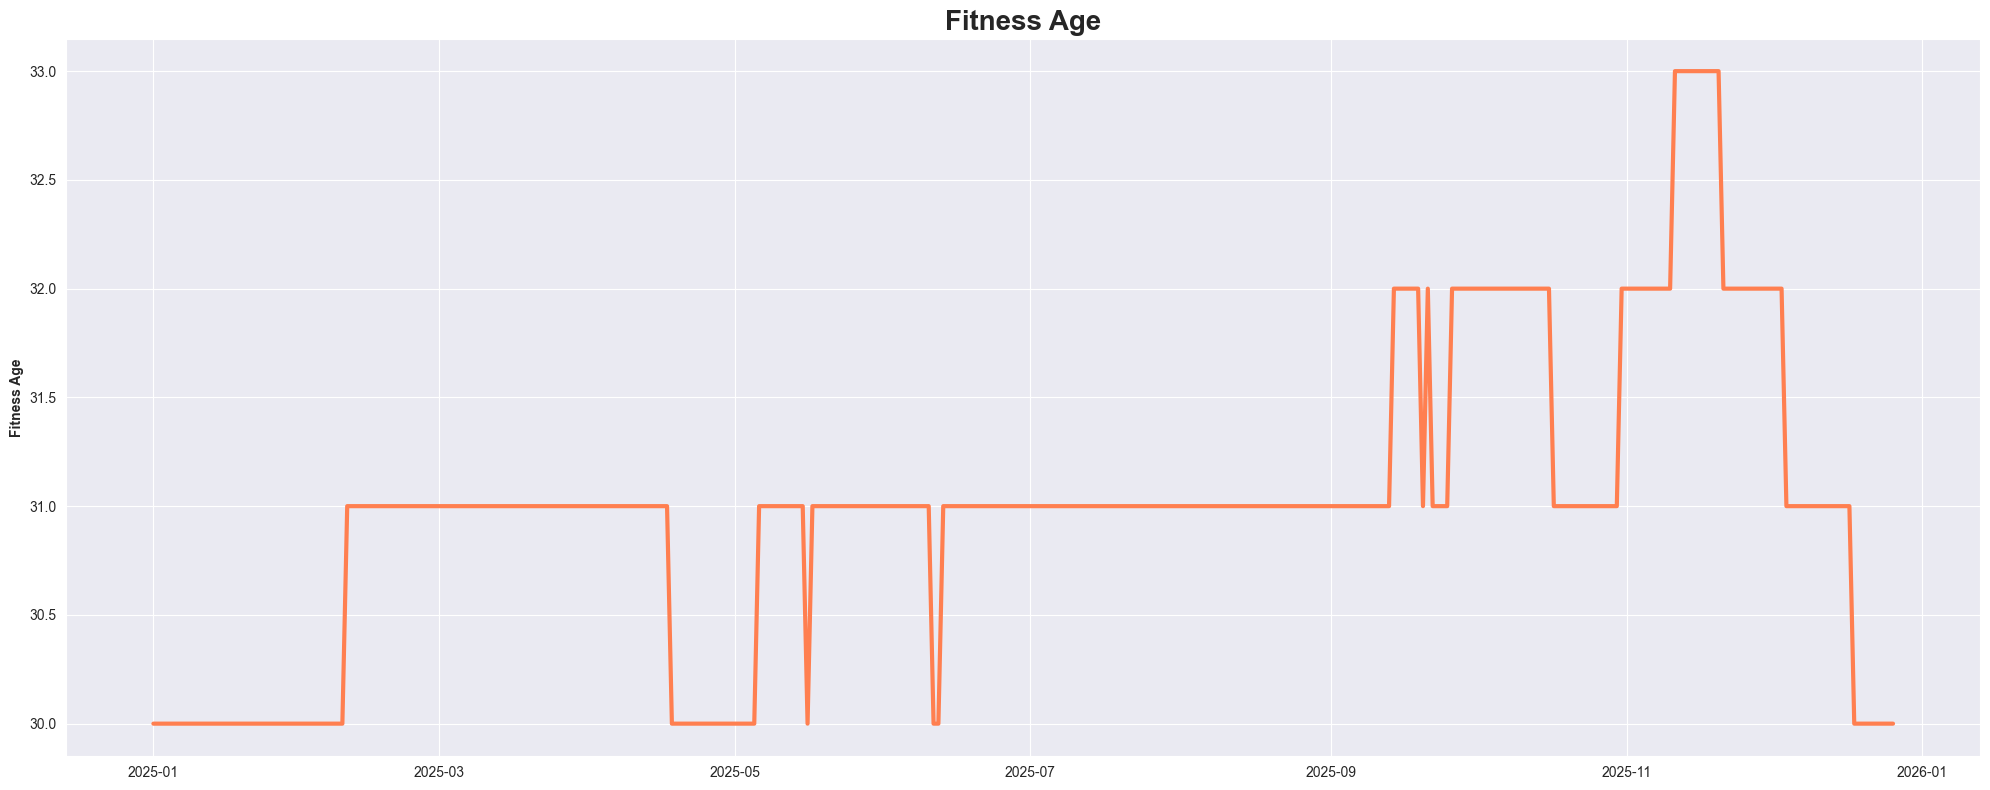

In [509]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Fitness Age'], color=MAIN_COLOR, linewidth=MAIN_LINE_WIDTH)
plt.title('Fitness Age', **TITLE_KKWARGS)
plt.ylabel('Fitness Age', fontweight='bold')
plt.tight_layout()
plt.show()

## Fitness Age Correlations

This visualization explores how Fitness Age relates to daily activity, exertion, and recovery metrics. By comparing Fitness Age against calories burned, total steps, highly active hours, and sleep score, the regression trends reveal which behaviors show stronger linear relationships with fitness outcomes. The results suggest that both physical activity intensity and sleep quality play meaningful roles in influencing Fitness Age over time.

-------------------------------------------------------------------------------------------------------------------------------------
Active hours show the most notable correlation with fitness age, with other factors contributing in secondary, yet important, ways.

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

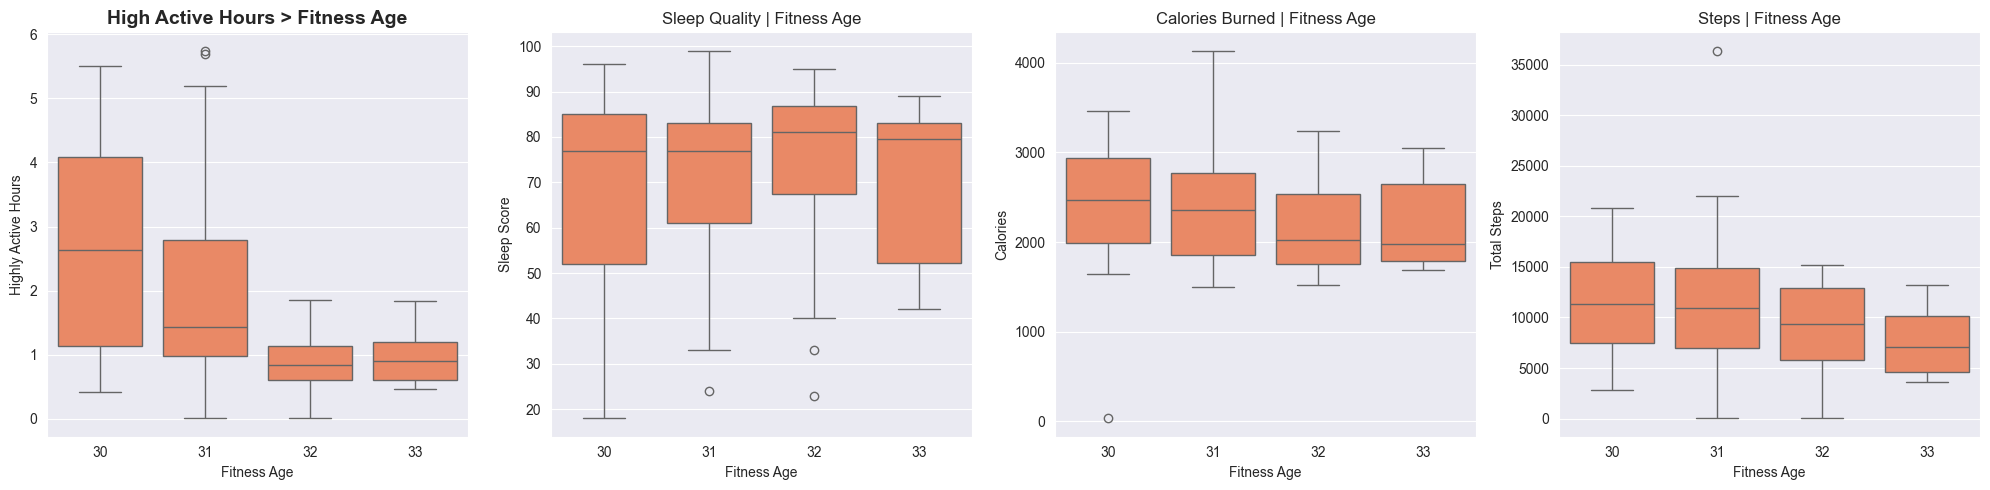

In [510]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

sns.boxplot(df_viz, x='Fitness Age', y='Highly Active Hours',  color=MAIN_COLOR, ax=ax1)
ax1.set_title('High Active Hours > Fitness Age', **SUB_TITLE_KKWARGS)

sns.boxplot(df_viz, x='Fitness Age', y='Sleep Score',  color=MAIN_COLOR, ax=ax2)
ax2.set_title('Sleep Quality | Fitness Age')

sns.boxplot(df_viz, x='Fitness Age', y='Calories',  color=MAIN_COLOR, ax=ax3)
ax3.set_title('Calories Burned | Fitness Age')

sns.boxplot(df_viz, x='Fitness Age', y='Total Steps',  color=MAIN_COLOR, ax=ax4)
ax4.set_title('Steps | Fitness Age')

plt.tight_layout()
plt.show()

# 💧 How Many Cups of Water Do I Drink a Day?

Water Intake tracks daily fluid consumption and is compared against a personalized hydration goal calculated by Garmin based on factors such as height, weight, and activity level. This metric provides context for daily hydration habits and helps assess consistency relative to recommended intake levels.

## Key Insights
* The recommended daily water intake is approximately 12 cups (96 oz), based on personalized hydration guidelines.
* Average daily water consumption is approximately 10.89 cups, indicating generally consistent hydration behavior.
* While daily intake does not always meet the recommended goal, overall consumption remains close to target levels across most days.
* Periods of lower intake are balanced by consistent hydration on other days, supporting stable hydration trends over time.


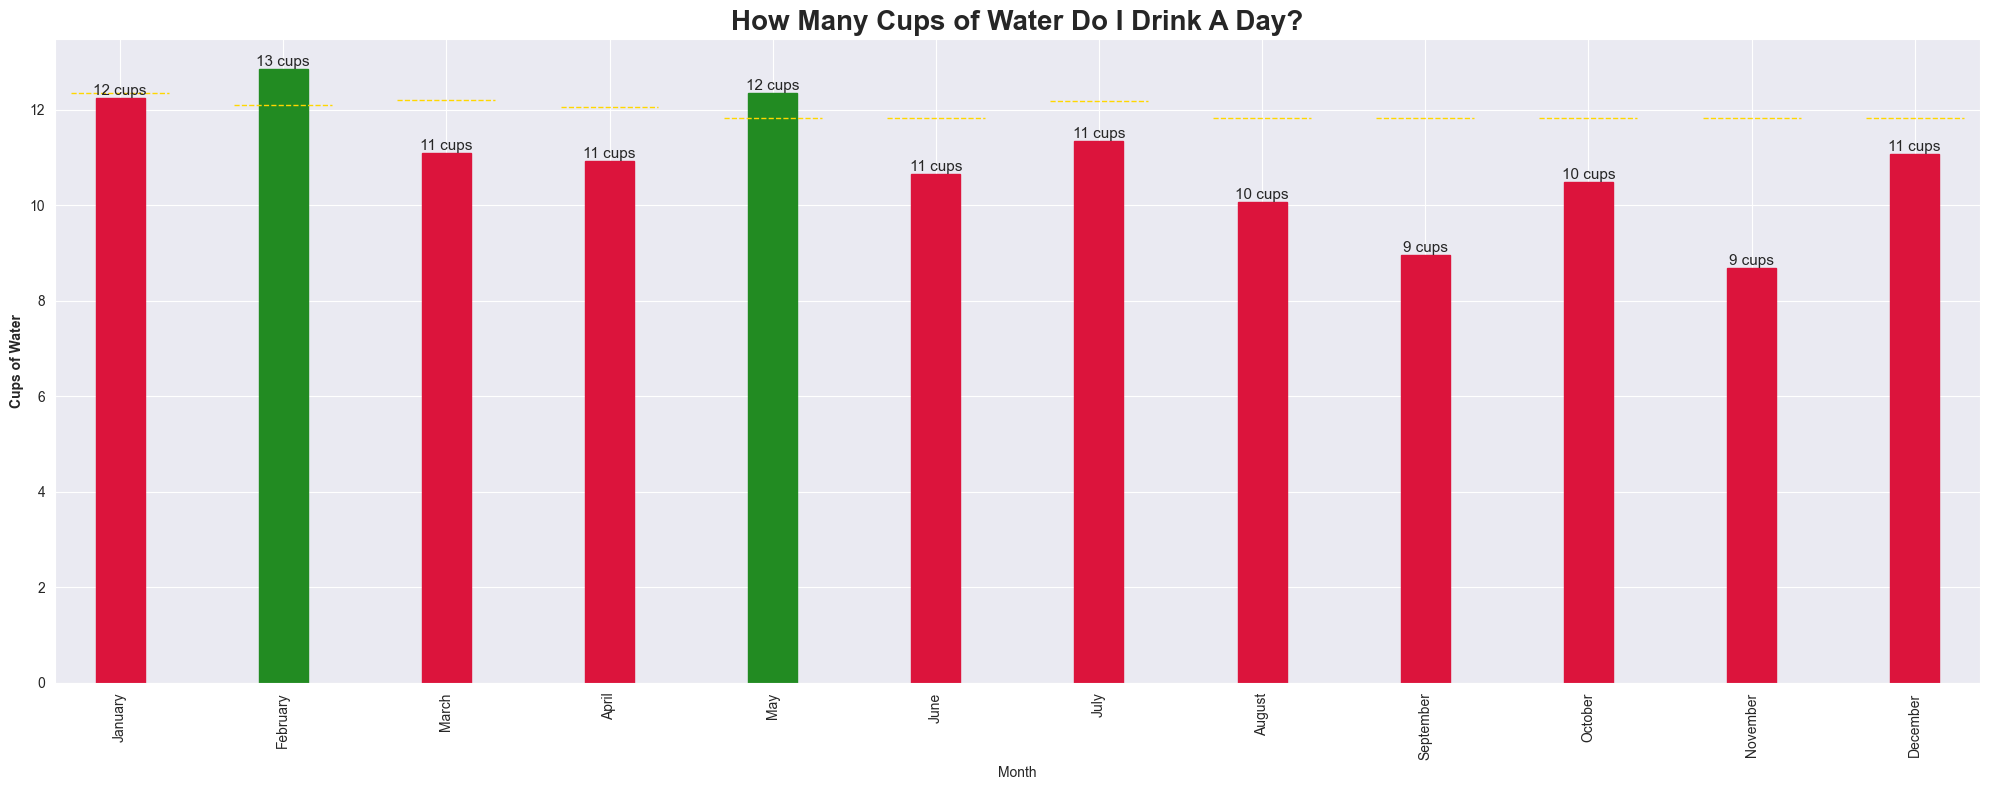

In [511]:
# df_viz['Hydration Value In Cups']
fig, ax = plt.subplots(figsize=(20, 8))

hydration_values = grp_month['Hydration Value In Cups'].mean()
hydration_values.plot(kind='bar', color=MAIN_COLOR, width=BAR_WIDTH, ax=ax)

# Set some goal lines
goals_values = grp_month['Hydration Goal In Cups']
for i, (month, goal) in enumerate(goals_values):
    ax.hlines(
        y=goal.mean(),
        xmin=i - .3,
        xmax=i + .3,
        color=REF_COLOR,
        linestyle='--',
        linewidth=1
    )

# Highly the bars where I reach my hydration goal
for bar, hydration_value, goals_value in zip(ax.patches, hydration_values, goals_values.mean()):
    color = POSITIVE_REF_COLOR if hydration_value >= goals_value else NEGATIVE_REF_COLOR
    height = bar.get_height()
    bar.set(color=color)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f} cups',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('How Many Cups of Water Do I Drink A Day?', **TITLE_KKWARGS)
plt.ylabel('Cups of Water', fontweight='bold')
plt.tight_layout()
plt.show()

# 💗 Heart Rate Data

Heart rate data provides insight into cardiovascular workload, recovery, and exercise intensity. During data collection, it was observed that Garmin does not store a daily average heart rate in the general summary tables. To address this, per-minute heart rate records were scraped and aggregated to calculate daily averages. However, Garmin appears to retain this high-granularity data for a limited time period, resulting in partial coverage of average heart rate values across the full dataset.

## Key Insights
* The calculated average heart rate is approximately 75 bpm, derived from per-minute heart rate data.
* Maximum recorded heart rate reached 179 bpm, typically occurring during high-intensity activity.
* Minimum heart rate values dropped to 39 bpm, reflecting periods of rest or sleep.
* Resting heart rate averages around 54 bpm, providing a baseline indicator of cardiovascular fitness and recovery.

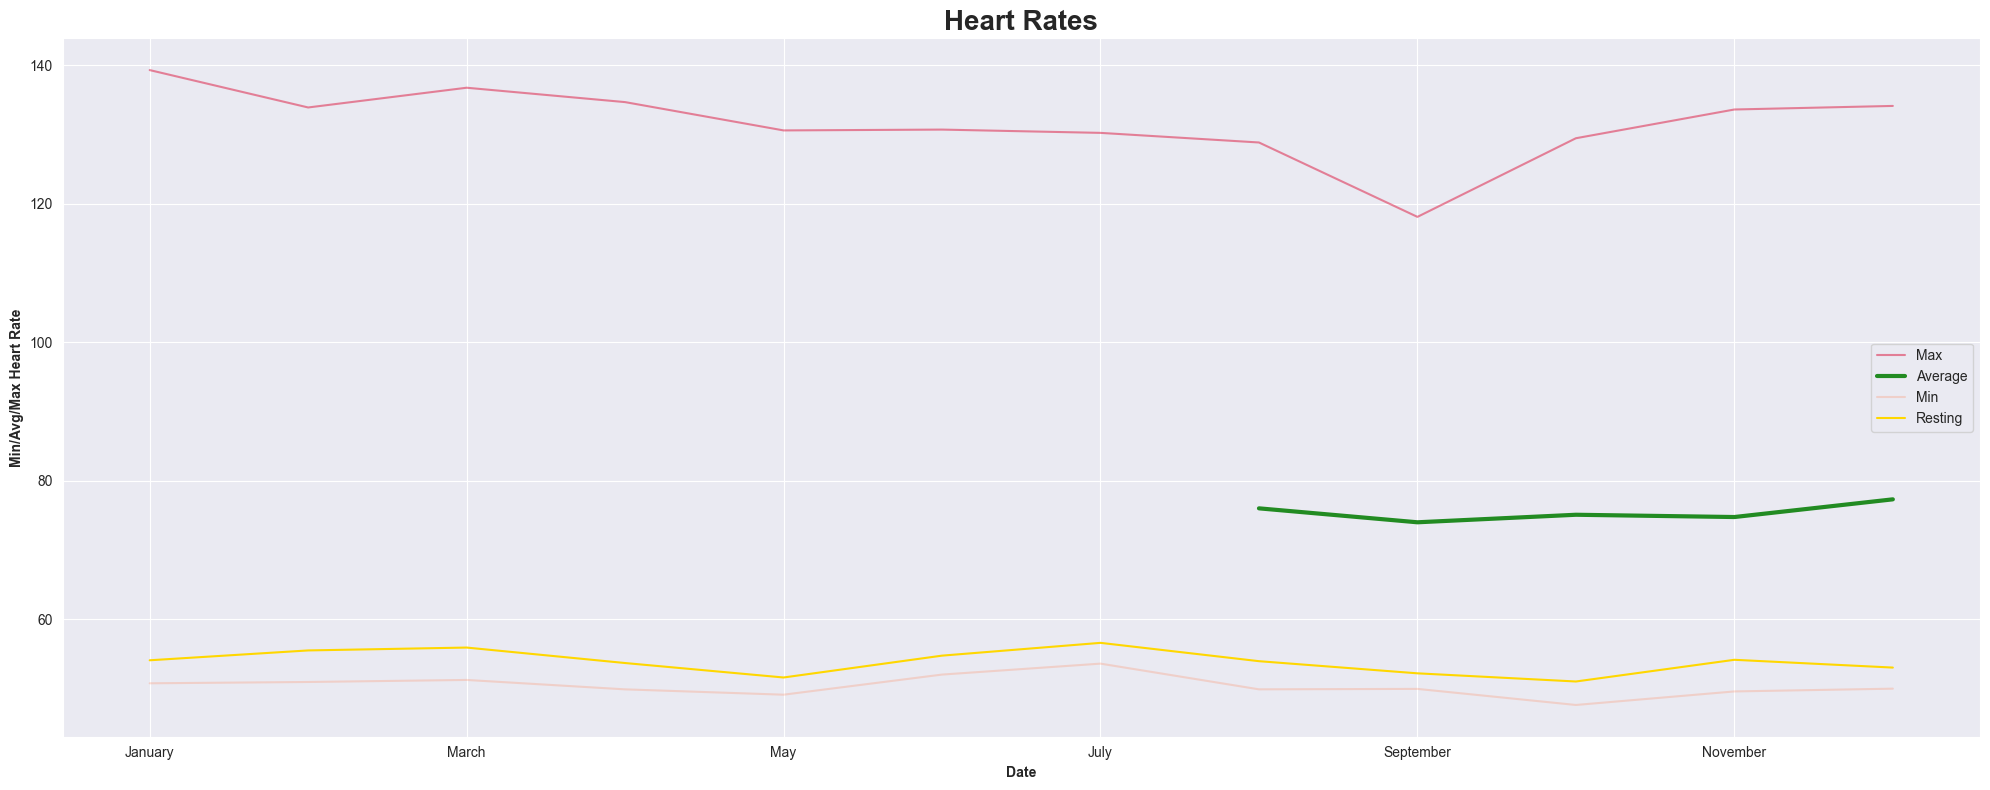

In [512]:
plt.figure(figsize=[20,8])

grp_month['Max Heart Rate'].mean().plot(color=NEGATIVE_REF_COLOR, alpha=.5)
grp_month['Average Heart Rate'].mean().plot( color=POSITIVE_REF_COLOR, linewidth=MAIN_LINE_WIDTH)
grp_month['Min Heart Rate'].mean().plot( color=MAIN_COLOR, alpha=.25)
grp_month['Resting Heart Rate'].mean().plot( color=REF_COLOR)

plt.title('Heart Rates', **TITLE_KKWARGS)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Min/Avg/Max Heart Rate', fontweight='bold')
plt.legend(['Max', 'Average', 'Min', 'Resting'])
plt.tight_layout()
plt.show()

# 🏃🏽‍♂️ Total Calories Burned and Active/Intenity Minutes
Total Calories Burned represents daily energy expenditure, combining basal metabolic rate with calories burned through physical activity. Active Hours and Intensity Minutes capture different dimensions of movement: Active Hours reflect consistent movement throughout the day, while Intensity Minutes measure time spent in moderate to vigorous activity. Together, these metrics provide a comprehensive view of daily activity volume and exertion.
This analysis spans multiple work schedule changes throughout the year, allowing for comparison of activity and calorie expenditure patterns across different routines and days of the week.

## Key Insights
* Average daily calorie expenditure is approximately **2,357 calories**, with a maximum of **4,134 calories** on high-activity days and a minimum near **1,500 calories**, aligning closely with estimated resting metabolic rate.
* Periods of higher calorie burn align with work schedule changes, resulting in concentrated activity patterns on specific weekdays.
* Higher calorie expenditure is generally associated with increased active hours and elevated intensity minutes, reflecting both sustained movement and purposeful exercise.
* Weekly Intensity Minutes are evaluated against Garmin’s guideline of 150 minutes per week, helping assess consistency in moderate-to-vigorous activity levels over time.

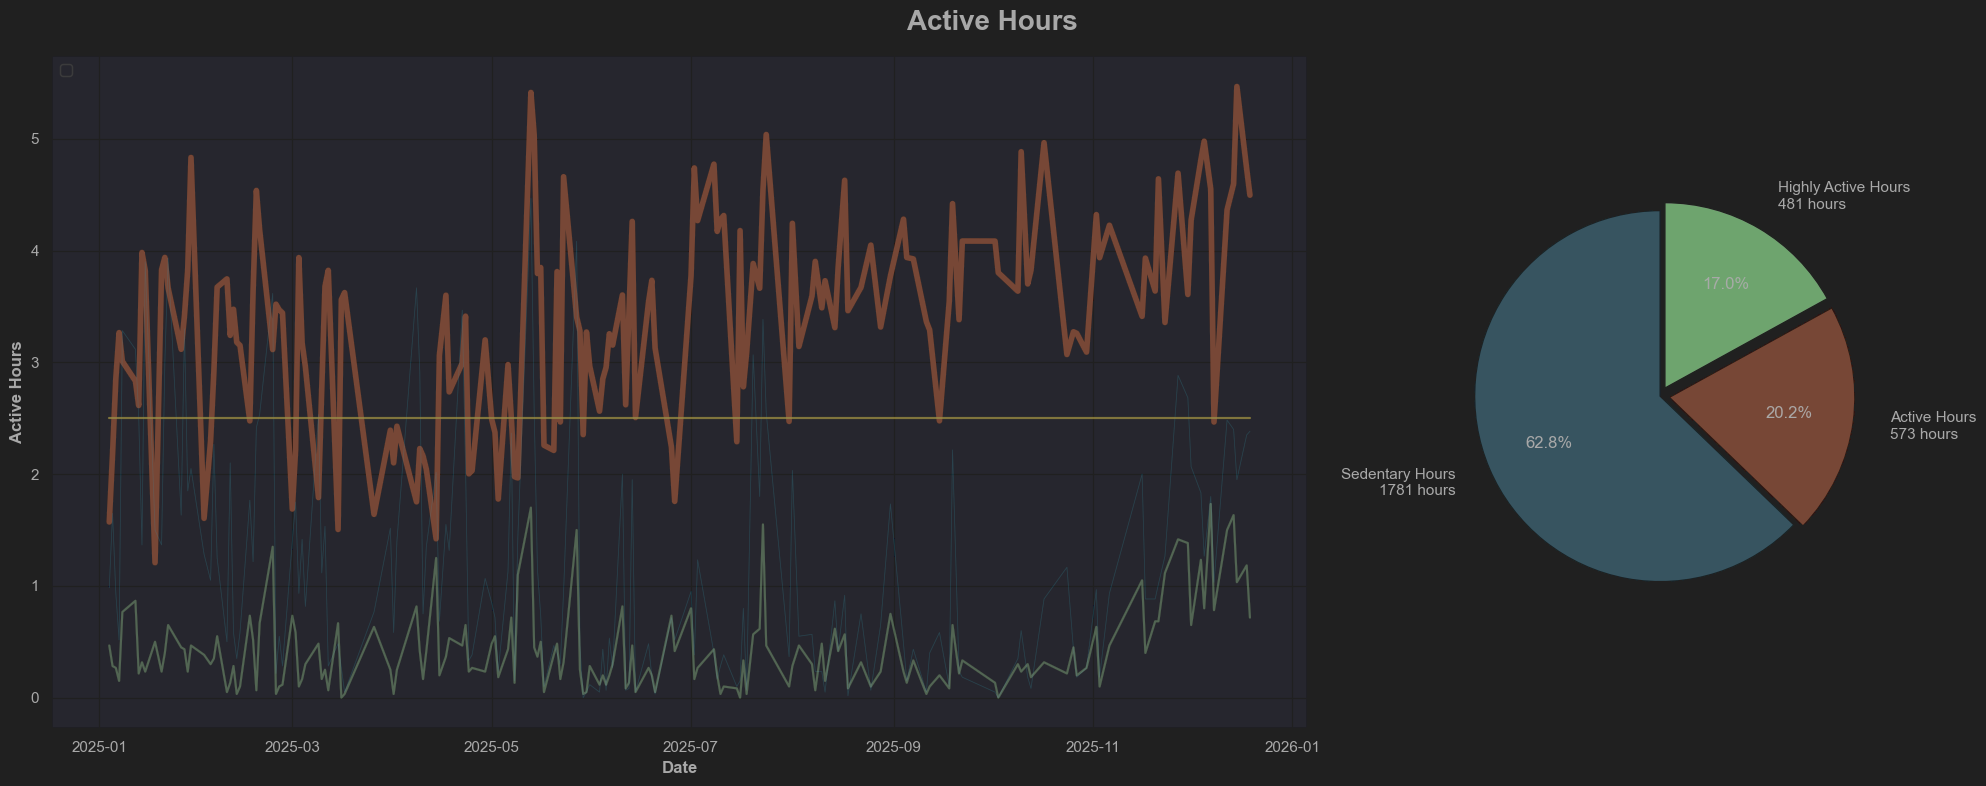
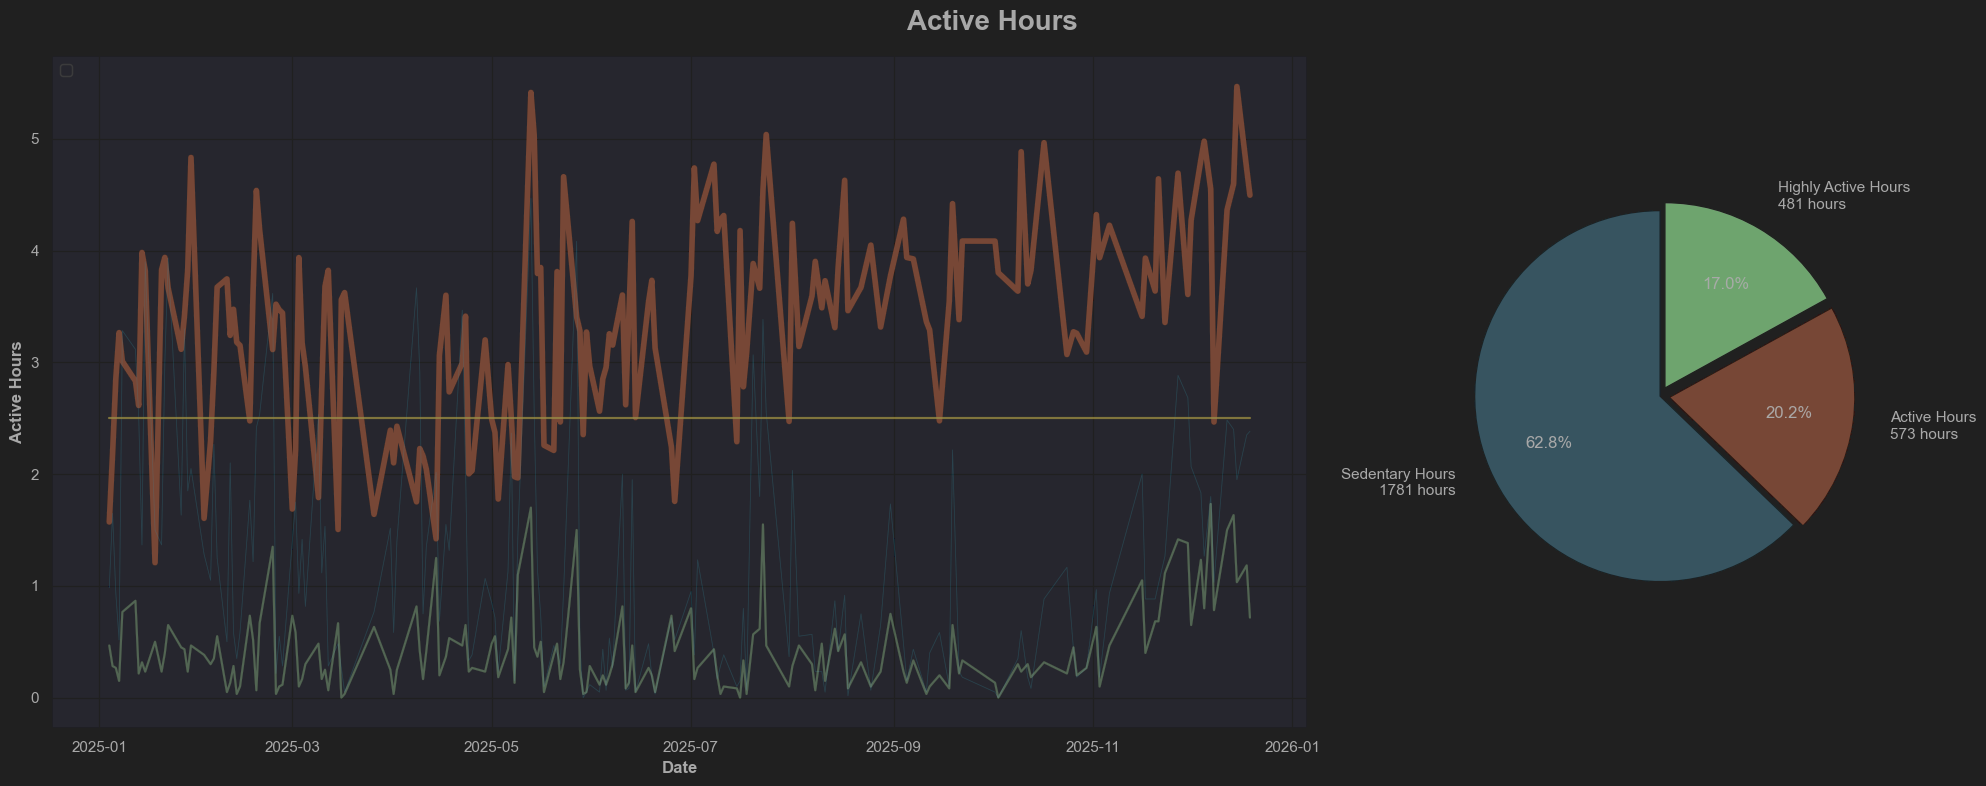

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_5671/2363786829.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = pivot.applymap(lambda x: f'{x:.0f} hrs')


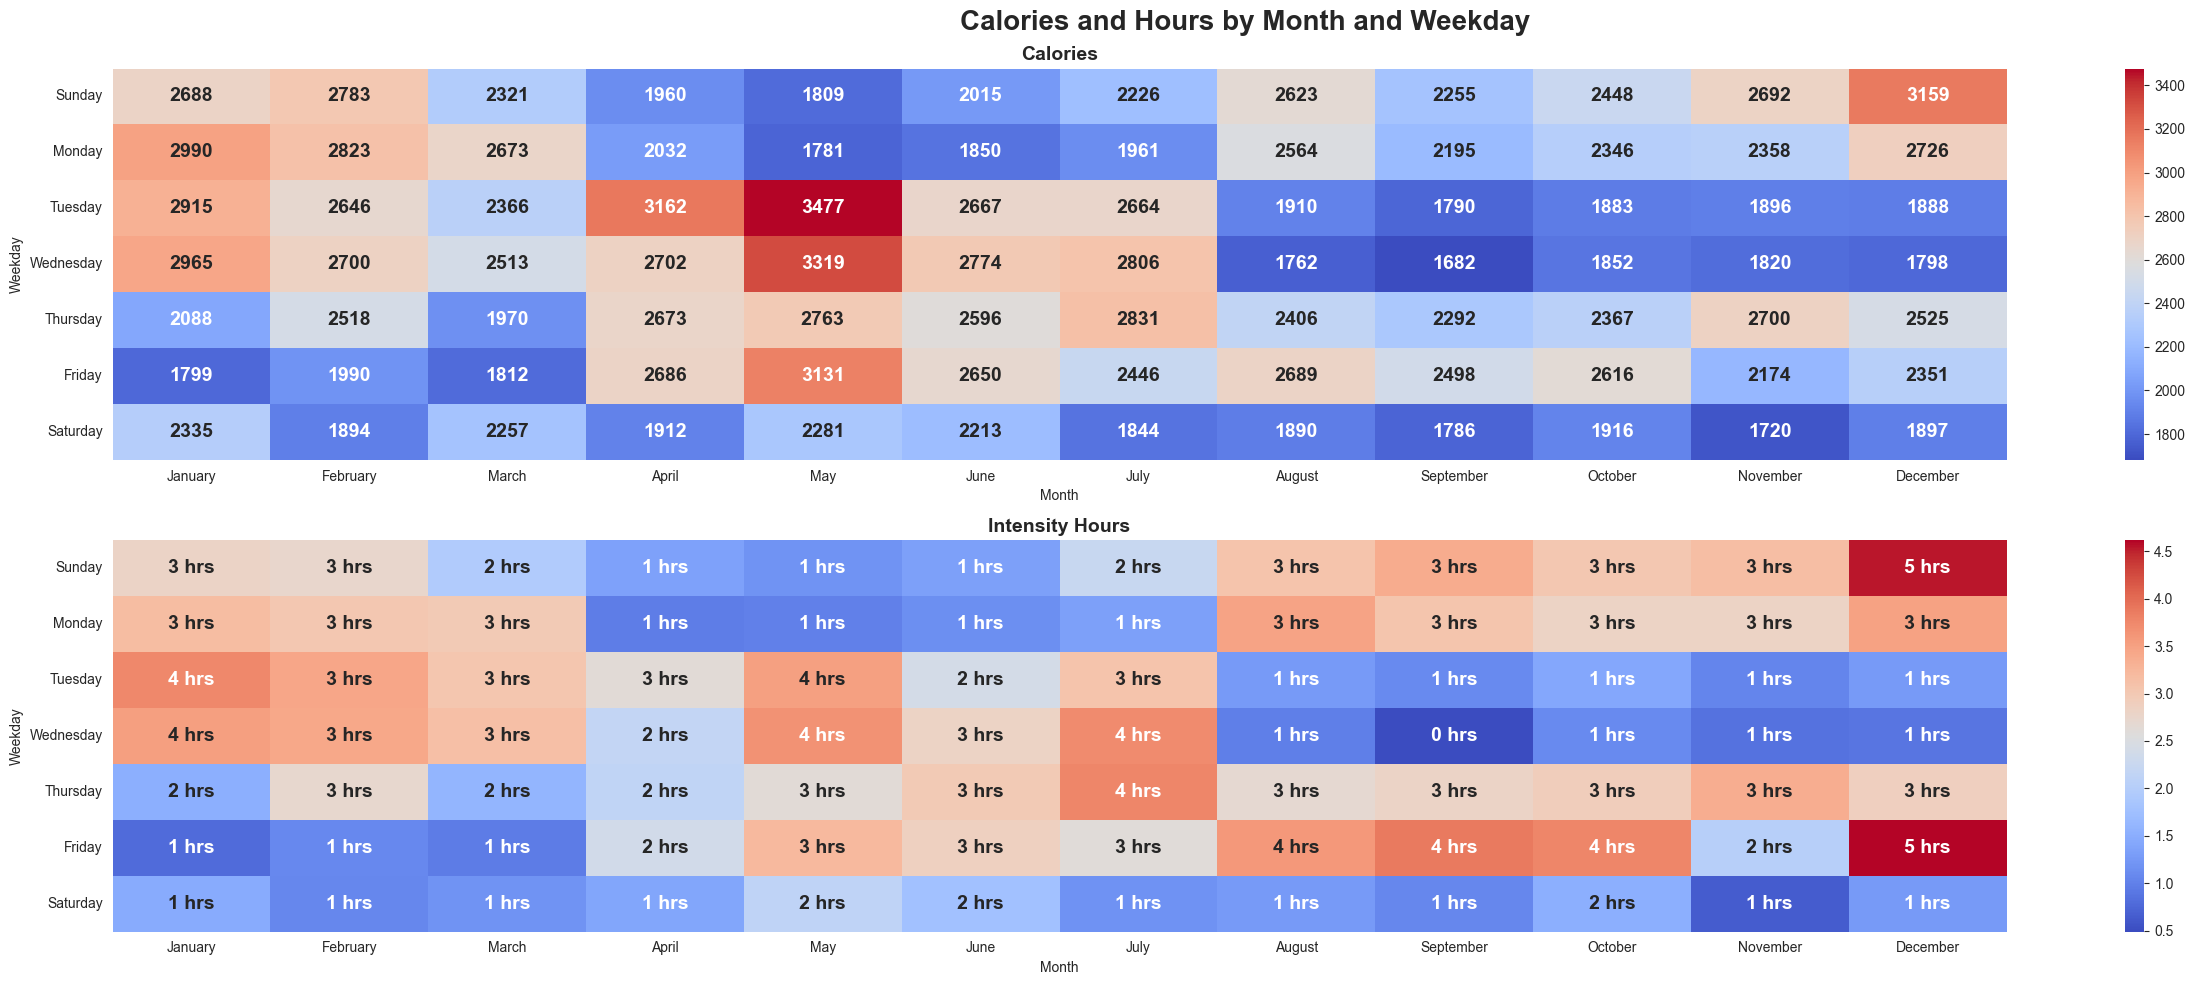

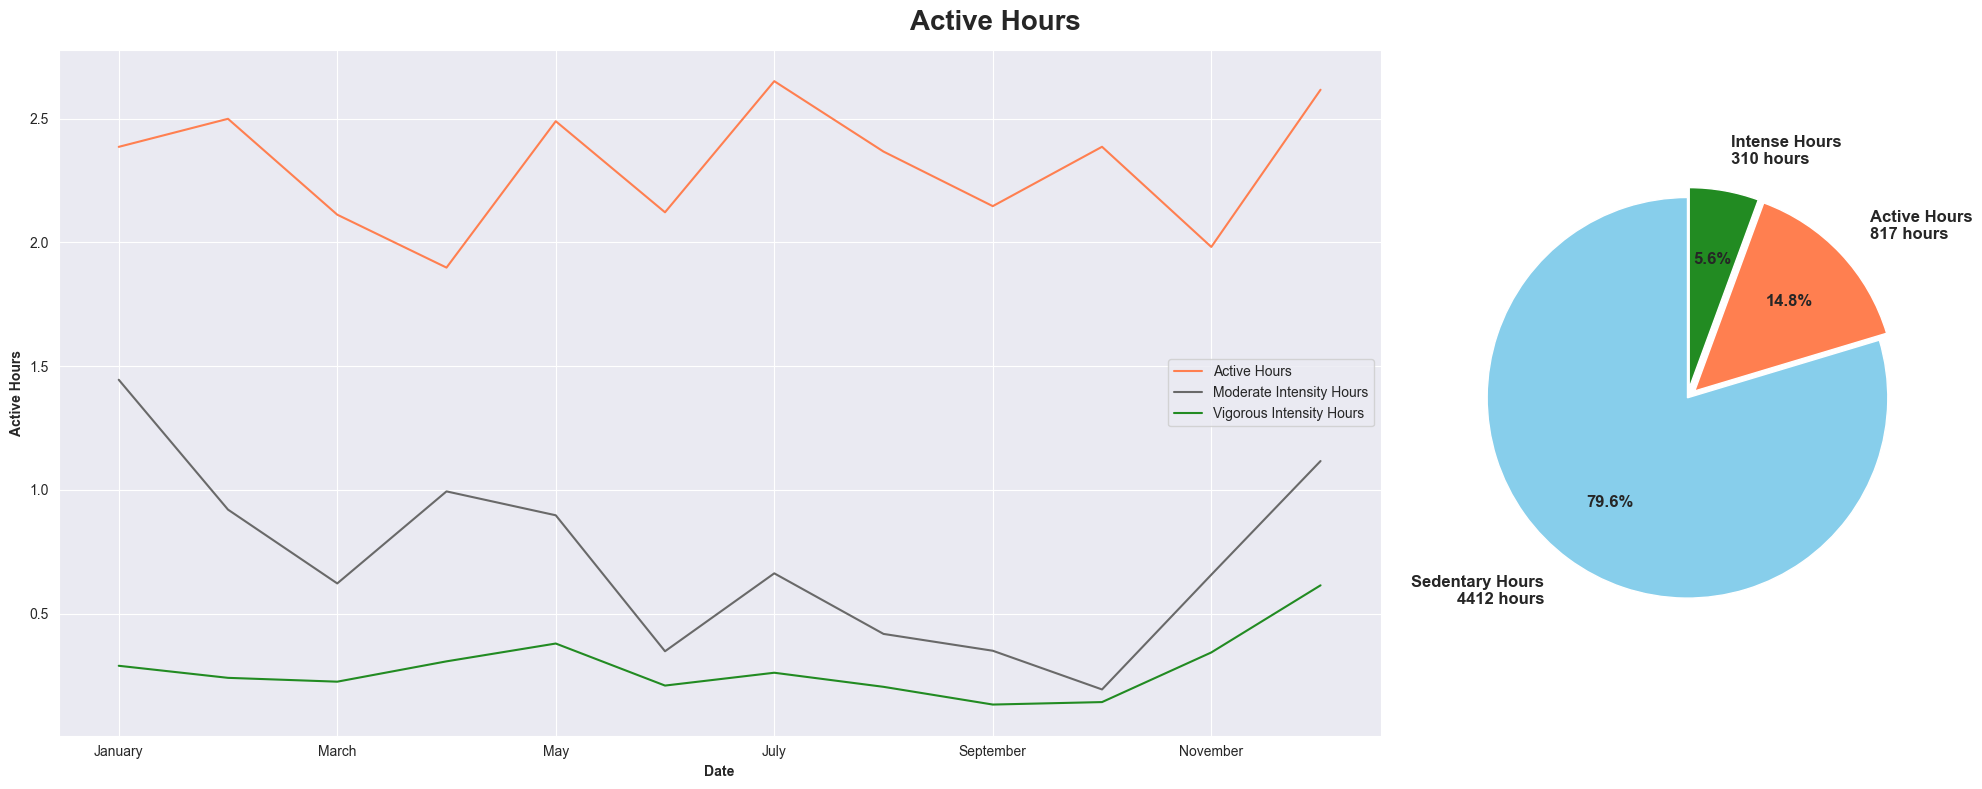

In [513]:
# Calorie and Intensity Hours
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(25, 10))
fig.suptitle('Calories and Hours by Month and Weekday', **TITLE_KKWARGS)
grp = grp_month_weekday['Calories'].mean().reset_index()
pivot = grp.pivot(index='Weekday', columns='Month', values='Calories')
sns.heatmap(pivot, annot=True, fmt='.0f', ax=ax1, cmap='coolwarm',
    annot_kws={
        'fontweight': 'bold',
        'fontsize': 14
    })
ax1.set_title('Calories', **SUB_TITLE_KKWARGS)

grp = grp_month_weekday['Active Hours'].mean().reset_index()
pivot = grp.pivot(index='Weekday', columns='Month', values='Active Hours')
annot_labels = pivot.applymap(lambda x: f'{x:.0f} hrs')
sns.heatmap(pivot, annot=annot_labels, fmt='', ax=ax2, cmap='coolwarm',
    annot_kws={
        'fontweight': 'bold',
        'fontsize': 14
    })
ax2.set_title('Intensity Hours', **SUB_TITLE_KKWARGS)
plt.tight_layout()
plt.show()

# Active Hours
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('Active Hours', **TITLE_KKWARGS)

grp_month['Active Hours'].mean().plot(color=MAIN_COLOR, ax=ax1)
grp_month[['Moderate Intensity Hours', 'Vigorous Intensity Hours']].mean().plot(color=[NEUTRAL_COLOR, POSITIVE_REF_COLOR], ax=ax1)
ax1.legend(loc='upper left')
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Active Hours', fontweight='bold')
ax1.legend(['Active Hours', 'Moderate Intensity Hours', 'Vigorous Intensity Hours'])

intense_hrs = df_viz['Moderate Intensity Hours'].sum() + df_viz['Vigorous Intensity Hours'].sum()
sizes = df_viz['Sedentary Hours'].sum(), df_viz['Active Hours'].sum(), intense_hrs
explode = (0, 0.05, 0.05)
labels = [f'Sedentary Hours\n{int(df_viz['Sedentary Hours'].sum())} hours', f'Active Hours\n{int(df_viz['Active Hours'].sum())} hours', f'Intense Hours\n{int(intense_hrs)} hours']
ax2.pie(sizes, labels=labels, explode=explode, autopct='%1.1f%%', pctdistance=.65, labeldistance=1.2, startangle=90, colors=['skyblue', MAIN_COLOR, POSITIVE_REF_COLOR], textprops={'fontweight': 'bold', 'fontsize': 12})
# ax2.font
ax2.axis('equal')

plt.tight_layout()
plt.show()

# 🚶🏽‍♂️ Total Steps Taken and Miles Walked
Steps Taken and Miles Walked measure overall daily movement and serve as core indicators of physical activity volume. Steps capture total movement throughout the day, while miles walked translate that activity into distance, providing additional context for activity intensity and duration. Together, these metrics help quantify daily mobility patterns and overall activity levels.

## Key Insights
* Average daily activity is approximately **10,729 steps**, indicating a consistently active baseline.
* Daily step counts vary significantly, with a maximum of **36,384 steps** recorded during a high-activity day (a long hike in the Columbia River Gorge on July 20), and a minimum of **21 steps**, representing a near-complete rest day.
* High-step days are typically associated with elevated calorie expenditure and longer active durations, while low-step days highlight periods of inactivity or recovery.
* Analyzing both steps and distance helps distinguish between frequent short movements and sustained walking or hiking sessions.

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_5671/2936198000.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


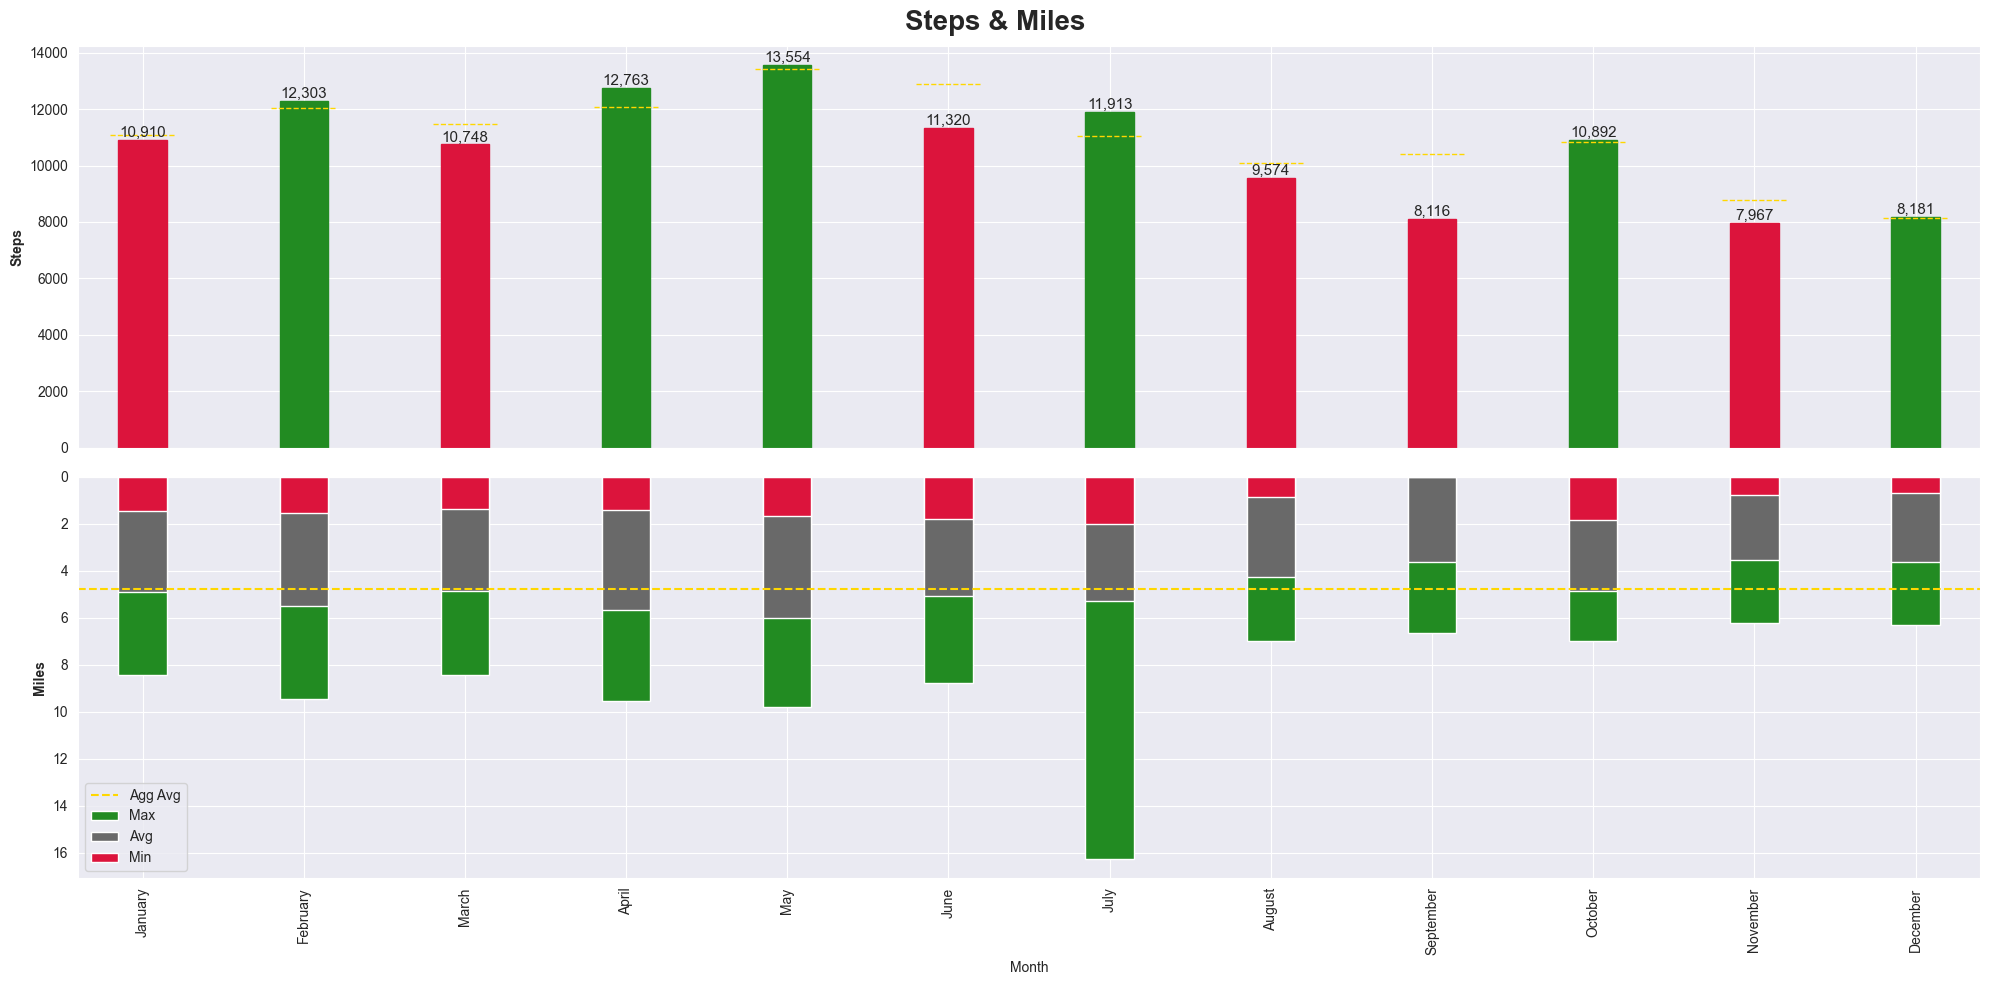

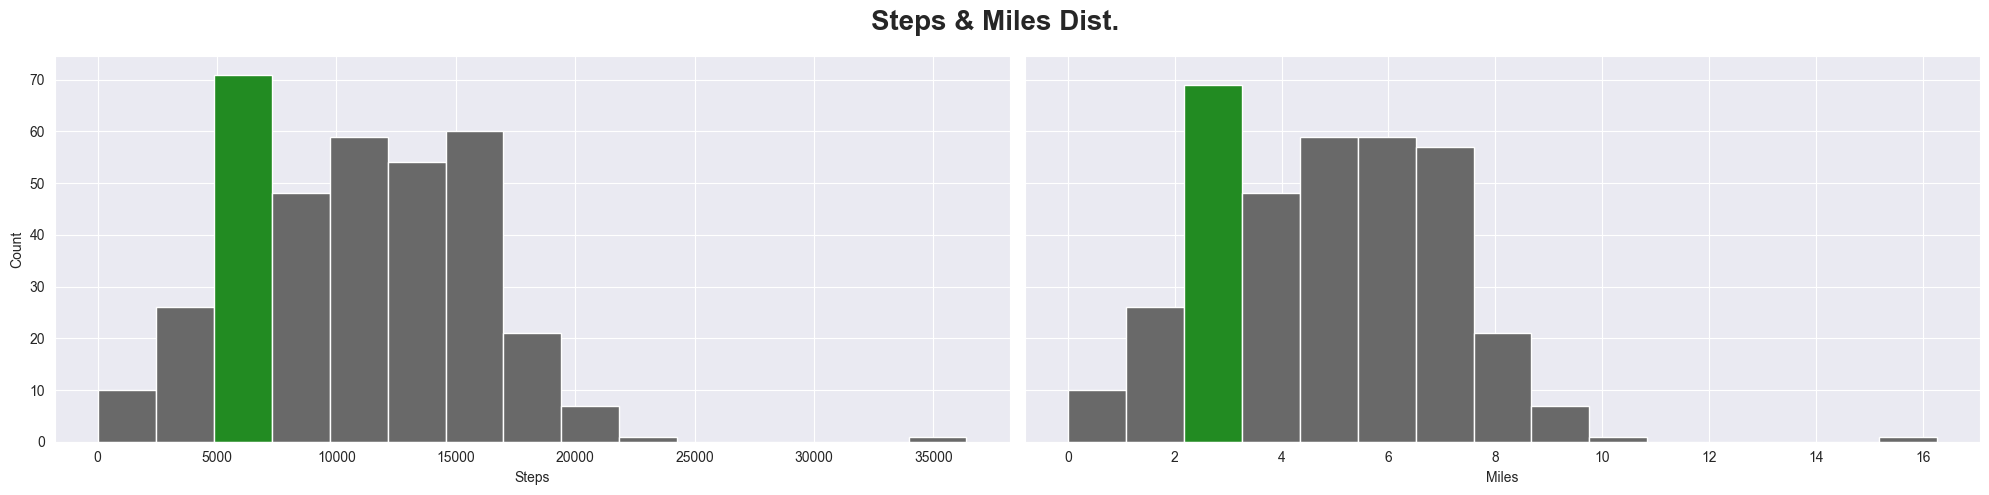

In [514]:
# Steps and Miles
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(20, 10), layout="constrained")
fig.suptitle('Steps & Miles', **TITLE_KKWARGS)

steps_values = grp_month['Total Steps'].mean()
steps_values.plot(kind='bar', ax=ax1, color=NEUTRAL_COLOR, width=BAR_WIDTH)
goals_values = grp_month['Daily Step Goal']
ax1.set_ylabel('Steps', fontweight='bold')

for i, (month, goal) in enumerate(goals_values):
    ax1.hlines(
        y=goal.mean(),
        xmin=i - 0.2,
        xmax=i + 0.2,
        color=REF_COLOR,
        linestyle='--',
        linewidth=1
    )
for bar, step_value, goals_value in zip(ax1.patches, steps_values, goals_values.mean()):
    color = POSITIVE_REF_COLOR if step_value >= goals_value else NEGATIVE_REF_COLOR
    height = bar.get_height()
    bar.set(color=color)
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

###
grp_month['Total Distance Miles'].max().plot(kind='bar', color=POSITIVE_REF_COLOR, ax=ax2, width=.3)
values = grp_month['Total Distance Miles'].mean()
values.plot(kind='bar', color=NEUTRAL_COLOR, ax=ax2, width=.3)
grp_month['Total Distance Miles'].min().plot(kind='bar', color=NEGATIVE_REF_COLOR, ax=ax2, width=.3)
ax2.axhline(y=df_viz['Total Distance Miles'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Total Distance Meters"].mean():.2f}')
ax2.invert_yaxis()
ax2.set_ylabel('Miles', fontweight='bold')
ax2.legend(['Agg Avg', 'Max', 'Avg', 'Min'])

plt.tight_layout()
plt.show()

# Steps & Miles Histogram
fig, (ax1, ax2) = plt.subplots(1, 2,  sharey=True, figsize=(20, 5))
fig.suptitle('Steps & Miles Dist.', **TITLE_KKWARGS)

counts, bins, patches = ax1.hist(df_viz['Total Steps'], bins=15, color=NEUTRAL_COLOR)
patches[counts.argmax()].set_facecolor(POSITIVE_REF_COLOR)
ax1.set_xlabel('Steps')
ax1.set_ylabel('Count')

counts, bins, patches = ax2.hist(df_viz['Total Distance Miles'], bins=15, color=NEUTRAL_COLOR)
patches[counts.argmax()].set_facecolor(POSITIVE_REF_COLOR)
ax2.set_xlabel('Miles')

plt.tight_layout()
plt.show()

# 💤 Sleep

Garmin’s Sleep Duration measures the total time spent asleep between sleep onset and wake time, providing a quantitative measure of nightly rest. Sleep Score is a composite metric that evaluates overall sleep quality using sleep duration, sleep stage distribution (light, deep, and REM), overnight stress, and recovery indicators. Analyzing these metrics together allows for a clear distinction between sleep quantity and sleep quality.

## Key Insights
* Sleep duration alone does not fully explain sleep quality; longer sleep does not always result in higher sleep scores.
* Higher sleep scores tend to align with improved recovery indicators and lower stress levels.
* Variability in sleep duration across days can have a noticeable impact on overall sleep quality trends.
* Examining both metrics together provides more actionable insight than analyzing either metric in isolation.

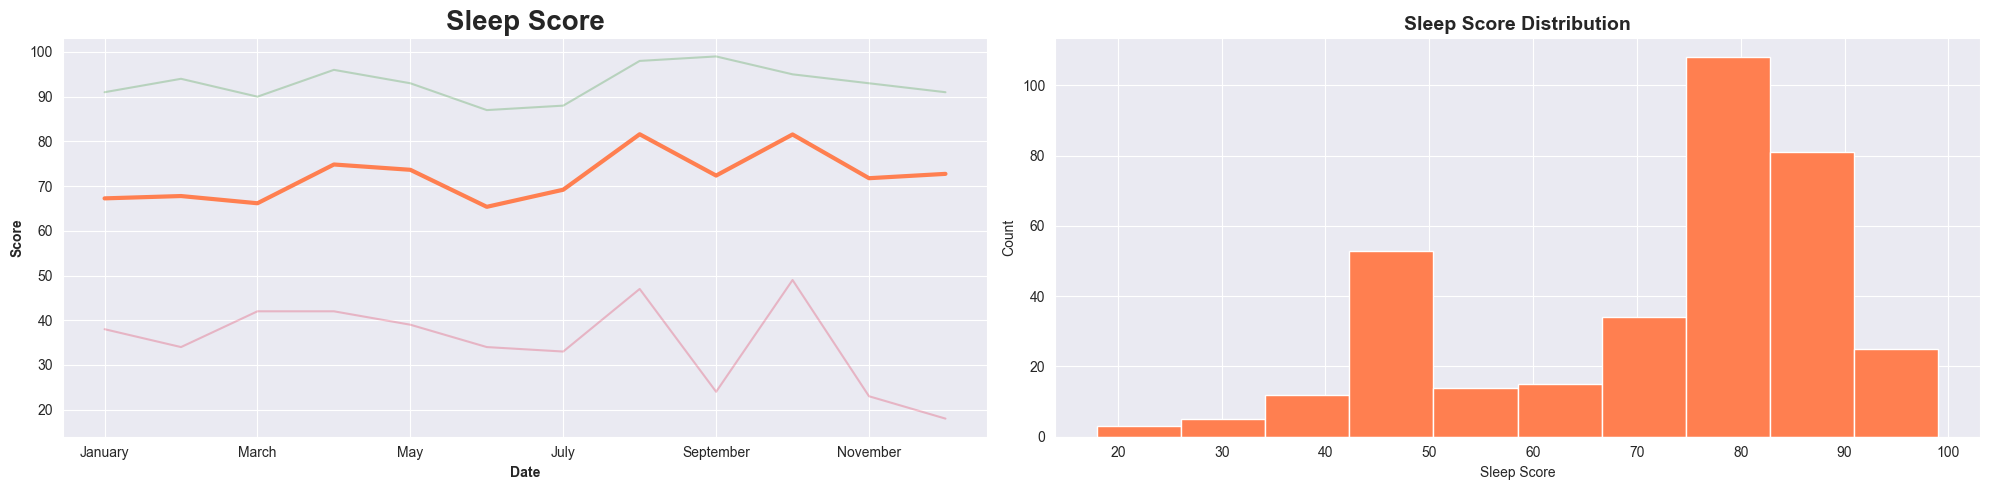

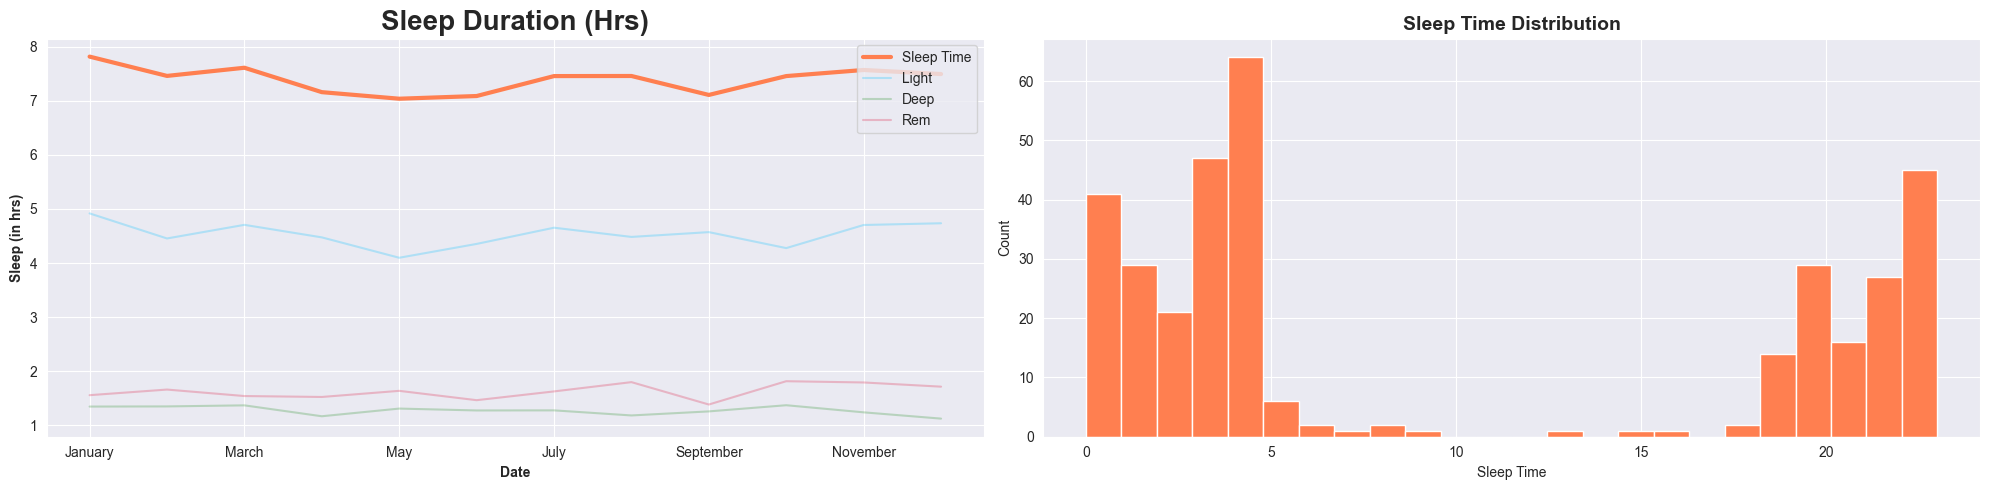

In [515]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
grp_month['Sleep Score'].max().plot(color=POSITIVE_REF_COLOR, alpha=.25, ax=ax1)
grp_month['Sleep Score'].mean().plot(color=MAIN_COLOR, linewidth=3, ax=ax1)
grp_month['Sleep Score'].min().plot(color=NEGATIVE_REF_COLOR, alpha=.25, ax=ax1)
ax1.set_title('Sleep Score', **TITLE_KKWARGS)
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax2.hist(df_viz['Sleep Score'], bins=10, color=MAIN_COLOR)
ax2.set_title('Sleep Score Distribution', **SUB_TITLE_KKWARGS)
ax2.set_xlabel('Sleep Score')
ax2.set_ylabel('Count')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

## What my aggregated sleep scores are

grp_month['Sleep Time Hours'].mean().plot(color=MAIN_COLOR, linewidth=3, ax=ax1)
grp_month['Light Sleep Hours'].mean().plot(color='deepskyblue', alpha=.25, ax=ax1)
grp_month['Deep Sleep Hours'].mean().plot(color='forestgreen', alpha=.25, ax=ax1)
grp_month['Rem Sleep Hours'].mean().plot( color='crimson', alpha=.25, ax=ax1)
ax1.set_title('Sleep Duration (Hrs)', **TITLE_KKWARGS)
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Sleep (in hrs)', fontweight='bold')
ax1.legend(['Sleep Time', 'Light', 'Deep', 'Rem'], loc='best')

ax2.hist(df_viz['Sleep Start Timestamp Local'].dt.hour, bins=24, color=MAIN_COLOR)
ax2.set_title('Sleep Time Distribution', **SUB_TITLE_KKWARGS)
ax2.set_xlabel('Sleep Time')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

# 😴 Sleep Quality

Sleep quality is evaluated using Garmin’s Sleep Score, which incorporates sleep duration, sleep stage distribution (light, deep, REM), and recovery indicators such as body battery and overnight stress. This analysis also examines sleep timing — specifically, sleep onset and wake times — to understand how these factors relate to sleep quality and overall recovery.

Average sleep score is **72 (min 18, max 99)** with **7.39 hours** of sleep on average **(min 3, max 13.5)**.

Regression analyses reveal that longer sleep generally improves sleep score and body battery, and better sleep may support higher calorie burn. Moderate active hours (around 1-2 hours) show a positive relationship with sleep quality, but extended high-intensity activity does not necessarily improve sleep. Sleep onset and wake times also influence sleep effectiveness, highlighting the importance of consistent sleep patterns. Sleep onset and wake times also influence sleep effectiveness, with better quality sleep observed when sleeping around 9 PM (on my off days) or 3 AM (on the days I work), highlighting the importance of consistent sleep patterns. Higher stress levels are associated with lower sleep scores, highlighting the interaction between physiological stress and recovery.

## Key Insights
* Sleep onset time significantly affects sleep quality: going to bed earlier is generally associated with higher sleep scores.
* Wake times and sleep consistency also contribute to overall recovery metrics.
* While moderate activity supports sleep, overly long or highly intense activity sessions do not guarantee improved sleep quality.
* Sleep score and duration provide complementary insights: duration reflects quantity, while sleep score captures quality and recovery effectiveness.


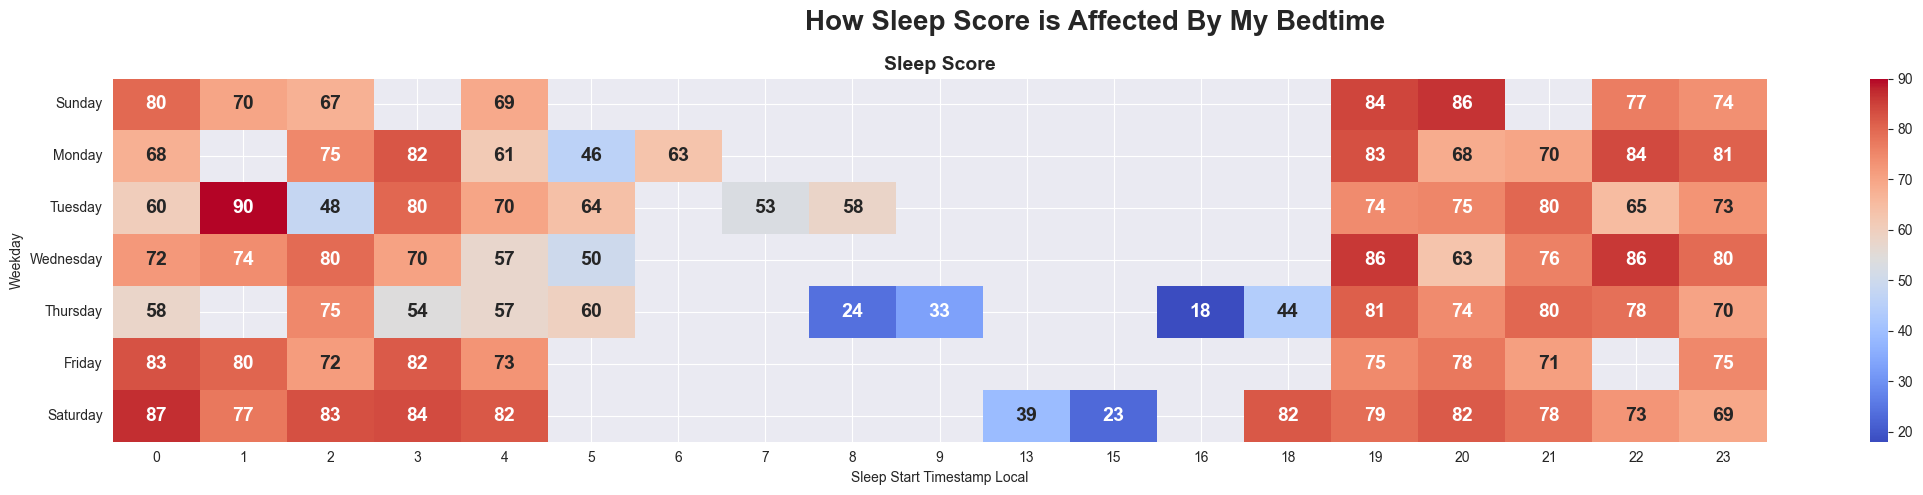

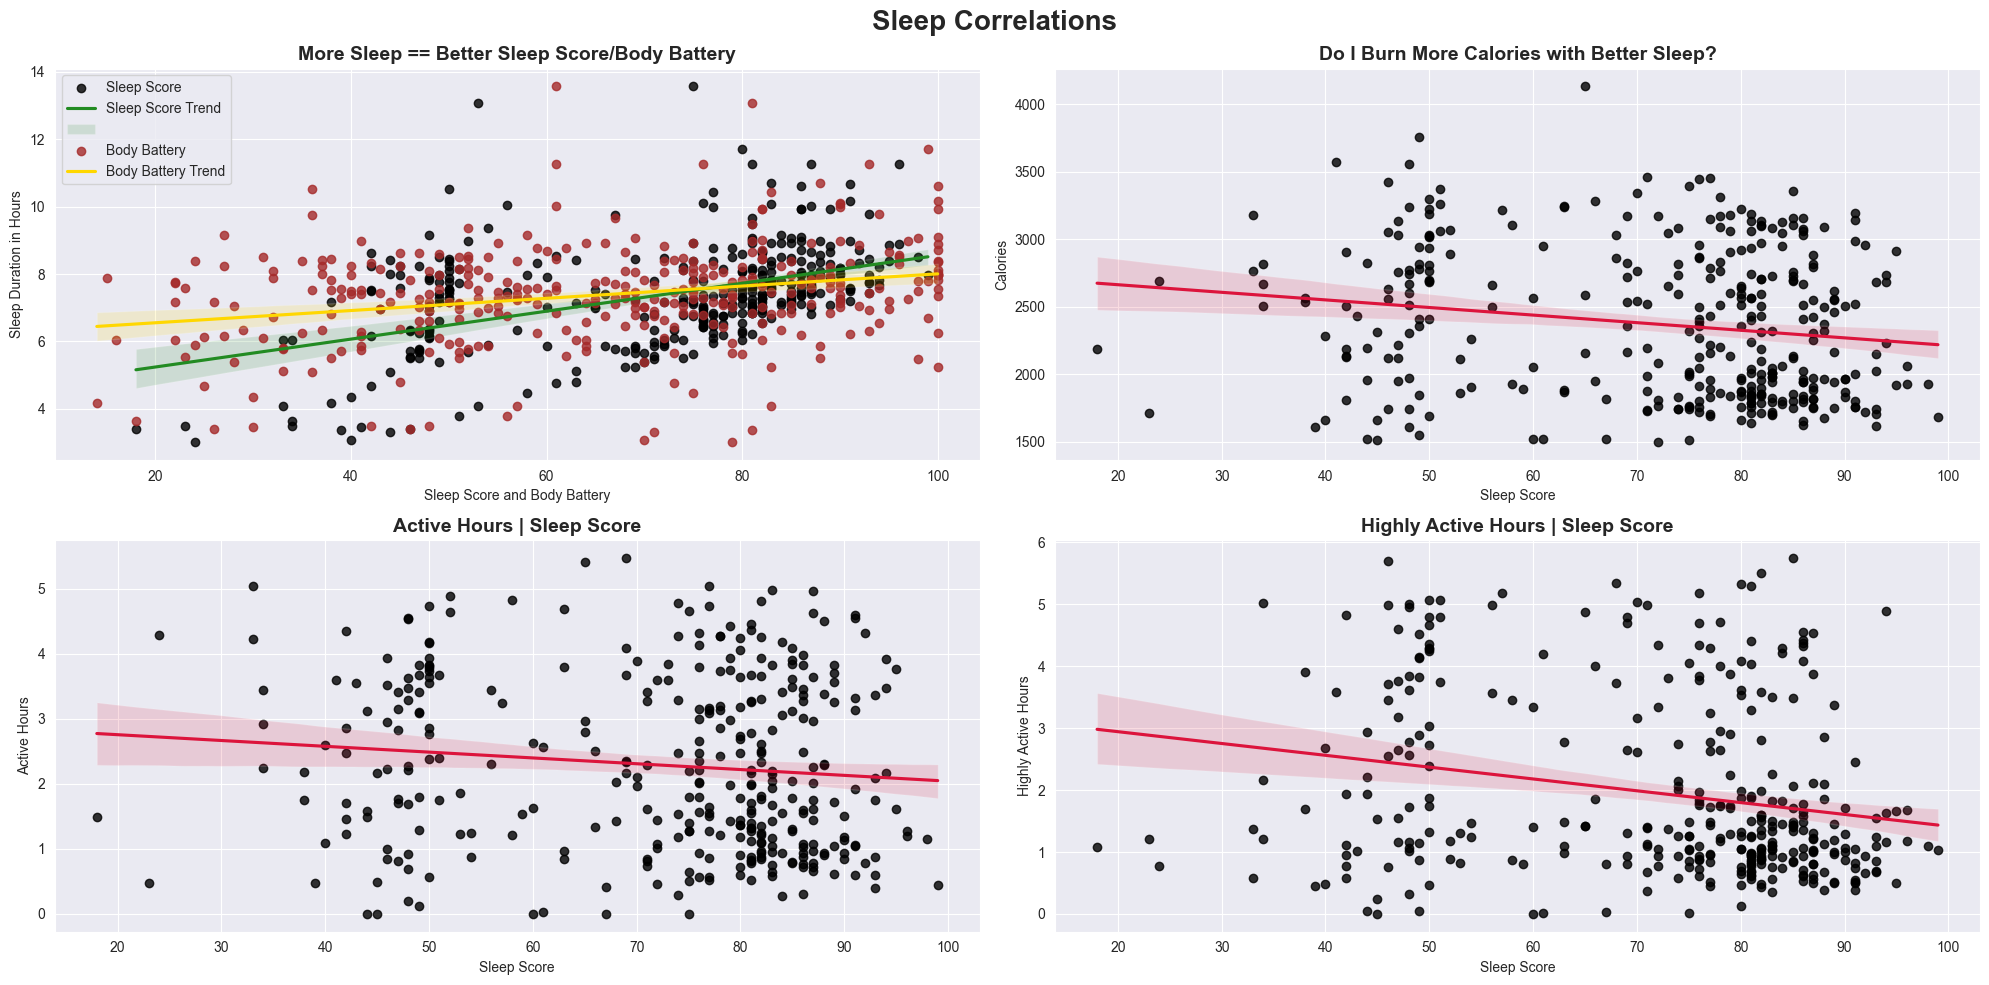

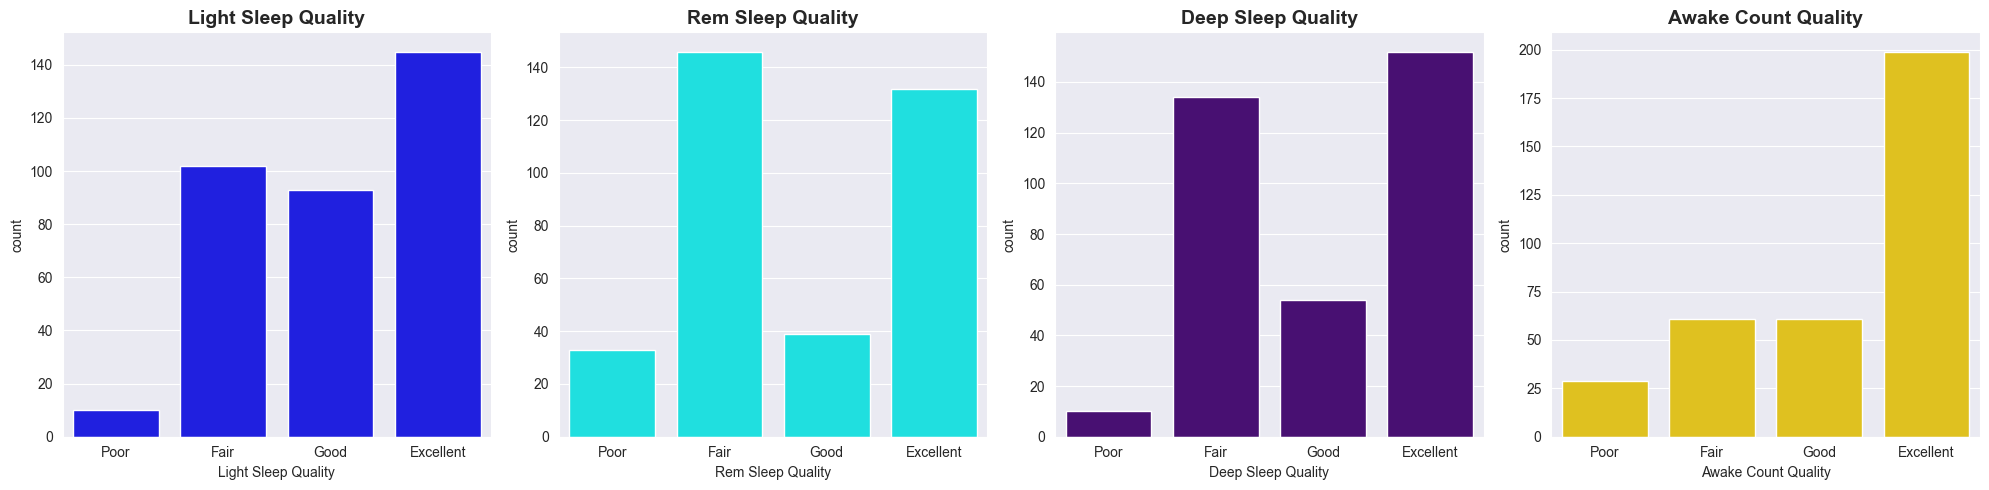

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_5671/4094901058.py:69: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.stripplot(df_viz, x='Sleep Quality', y='Average Stress Level', color=MAIN_COLOR, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax2)
/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_5671/4094901058.py:78: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.swarmplot(df_viz, x='Sleep Quality', y=df_viz['Stress Seconds'] / 3600, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, color=MAIN_COLOR, order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax4)


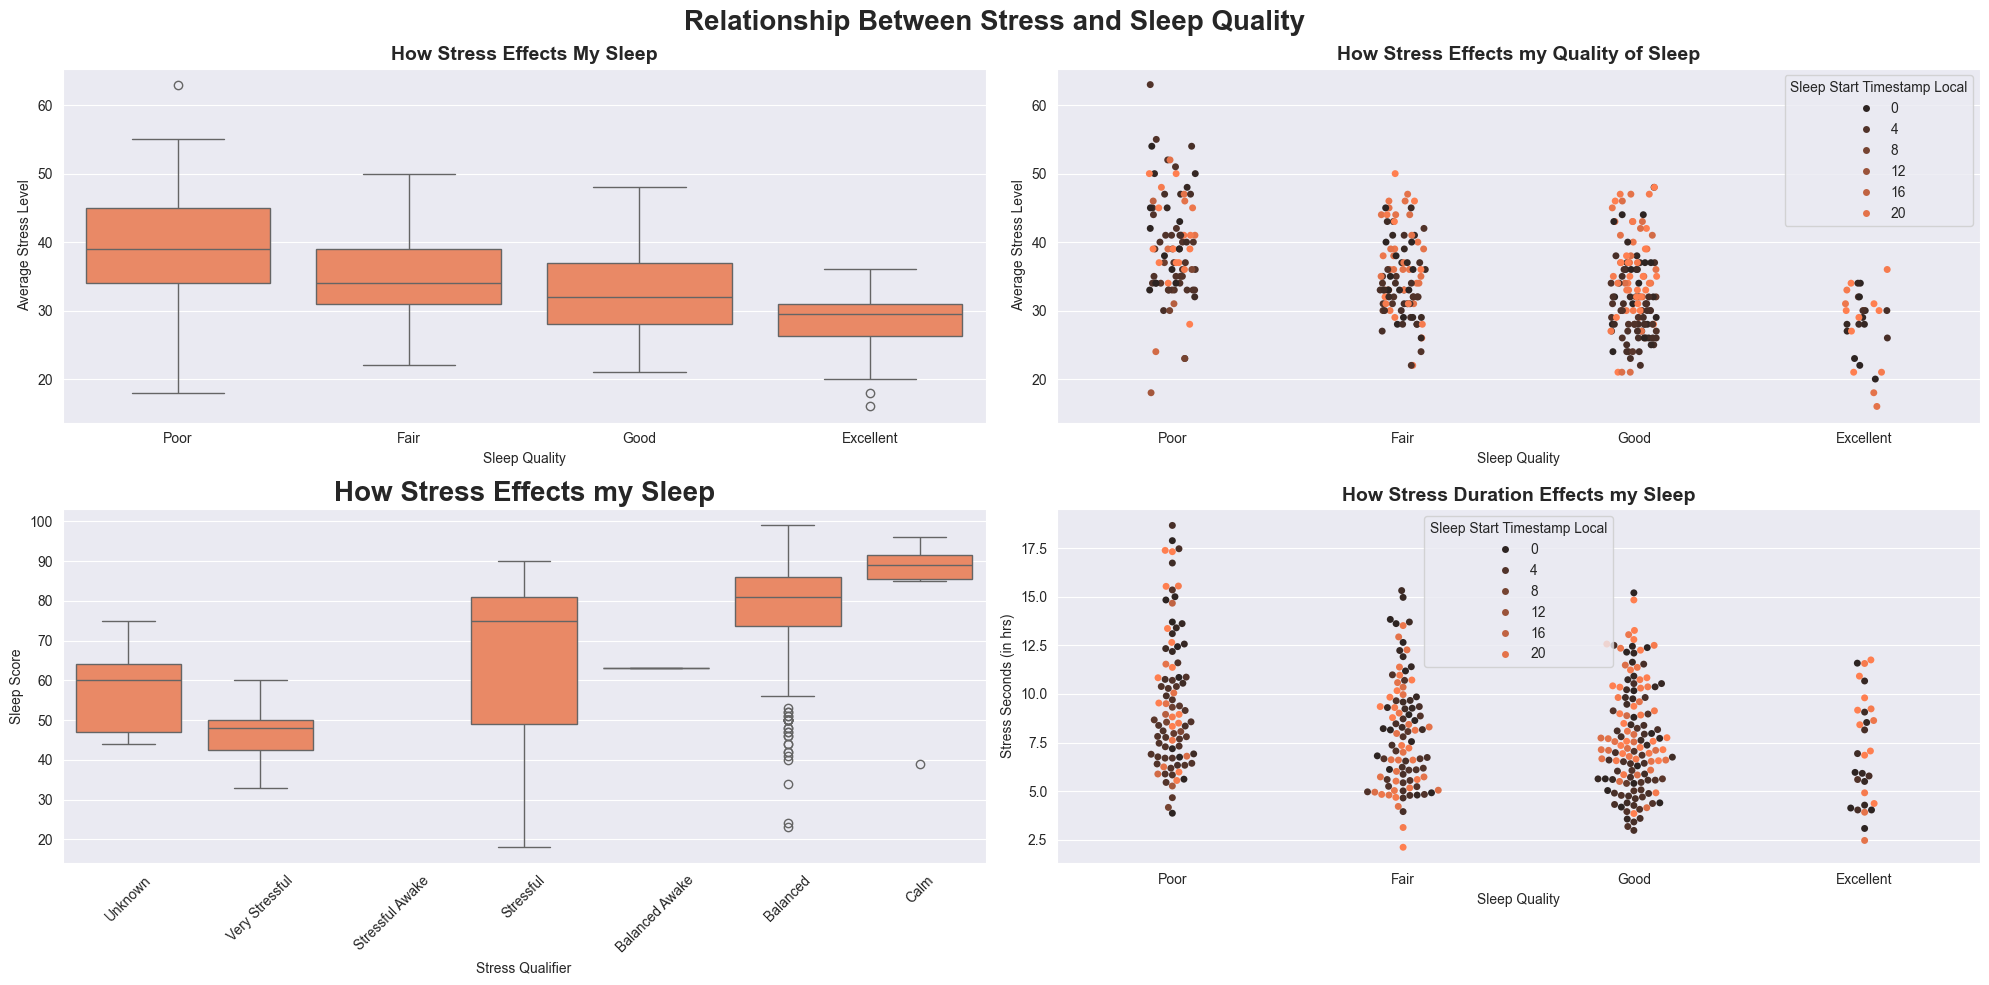

In [516]:
# Sleep Quality
fig, ax1 = plt.subplots(figsize=(22, 5))
fig.suptitle('How Sleep Score is Affected By My Bedtime', **TITLE_KKWARGS)
grp = grp_weekday_time['Sleep Score'].mean().reset_index()
pivot = grp.pivot(index='Weekday', columns='Sleep Start Timestamp Local', values='Sleep Score')
sns.heatmap(pivot, annot=True, fmt='.0f', ax=ax1, cmap='coolwarm',
    annot_kws={
        'fontweight': 'bold',
        'fontsize': 14
    })
ax1.set_title('Sleep Score', **SUB_TITLE_KKWARGS)
plt.tight_layout()
plt.show()


fig, ((ax3, ax4), (ax5, ax6)) = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.suptitle('Sleep Correlations', **TITLE_KKWARGS)
sns.regplot(df_viz, x='Sleep Score', y=df_viz['Sleep Time Seconds'] / 3600, scatter_kws={'color': 'k'}, line_kws={'color': POSITIVE_REF_COLOR}, ax=ax3)
sns.regplot(df_viz, x='Body Battery', y=df_viz['Sleep Time Seconds'] / 3600, scatter_kws={'color': 'brown'}, line_kws={'color': REF_COLOR}, ax=ax3)
ax3.set_title('More Sleep == Better Sleep Score/Body Battery', **SUB_TITLE_KKWARGS)
ax3.legend(['Sleep Score', 'Sleep Score Trend', '', 'Body Battery', 'Body Battery Trend'])
ax3.set_xlabel('Sleep Score and Body Battery')
ax3.set_ylabel('Sleep Duration in Hours')

sns.regplot(df_viz, x='Sleep Score', y='Calories', scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax4)
ax4.set_title('Do I Burn More Calories with Better Sleep?', **SUB_TITLE_KKWARGS)

sns.regplot(df_viz, x='Sleep Score', y=df_viz['Active Seconds'] / 3600, scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax5)
ax5.set_title('Active Hours | Sleep Score', **SUB_TITLE_KKWARGS)
ax5.set_ylabel('Active Hours')
sns.regplot(df_viz, x='Sleep Score', y=df_viz['Highly Active Seconds'] / 3600, scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax6)
ax6.set_title('Highly Active Hours | Sleep Score', **SUB_TITLE_KKWARGS)
ax6.set_ylabel('Highly Active Hours')

plt.tight_layout()
plt.show()

# Sleep Quality
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
sns.countplot(df_viz, x='Light Sleep Quality', color='blue', order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax1)
ax1.set_title('Light Sleep Quality', **SUB_TITLE_KKWARGS)

sns.countplot(df_viz, x='Rem Sleep Quality', color='aqua', order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax2)
ax2.set_title('Rem Sleep Quality', **SUB_TITLE_KKWARGS)


sns.countplot(df_viz, x='Deep Sleep Quality', color='indigo', order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax3)
ax3.set_title('Deep Sleep Quality', **SUB_TITLE_KKWARGS)


sns.countplot(df_viz, x='Awake Count Quality', color=REF_COLOR, order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax4)
ax4.set_title('Awake Count Quality', **SUB_TITLE_KKWARGS)

plt.tight_layout()
plt.show()

# sns.regplot(df_viz, x='Sleep Score', y='Highly Active Seconds', scatter_kws={'color': 'k'}, line_kws={'color': REF_COLOR}, ax=ax4)


# Stress and Sleep Quality
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.suptitle('Relationship Between Stress and Sleep Quality', **TITLE_KKWARGS)

sns.boxplot(df_viz, x='Sleep Quality', y='Average Stress Level', color=MAIN_COLOR, order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax1)
ax1.set_ylabel('Average Stress Level')
ax1.set_xlabel('Sleep Quality')
ax1.set_title('How Stress Effects My Sleep', **SUB_TITLE_KKWARGS)

sns.stripplot(df_viz, x='Sleep Quality', y='Average Stress Level', color=MAIN_COLOR, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax2)
ax2.set_ylabel('Average Stress Level')
ax2.set_xlabel('Sleep Quality')
ax2.set_title('How Stress Effects my Quality of Sleep', **SUB_TITLE_KKWARGS)

g = sns.boxplot(df_viz, x='Stress Qualifier', y='Sleep Score', color=MAIN_COLOR, order=['Unknown', 'Very Stressful', 'Stressful Awake', 'Stressful', 'Balanced Awake', 'Balanced', 'Calm'], ax=ax3)
ax3.set_title('How Stress Effects my Sleep', **TITLE_KKWARGS)
ax3.tick_params(axis='x', rotation=45)

sns.swarmplot(df_viz, x='Sleep Quality', y=df_viz['Stress Seconds'] / 3600, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, color=MAIN_COLOR, order=['Poor', 'Fair', 'Good', 'Excellent'], ax=ax4)
ax4.set_ylabel('Stress Seconds (in hrs)')
ax4.set_title('How Stress Duration Effects my Sleep', **SUB_TITLE_KKWARGS)

plt.tight_layout()
plt.show()

# 😰 Stress Data

Garmin estimates stress levels using heart rate variability (HRV) derived from optical heart rate sensors, combined with other physiological signals such as heart rate and respiration rate. The proprietary algorithm generates a body battery score and assigns a stress level throughout the day, reflecting both acute and cumulative stress. Higher stress levels correspond to lower recovery capacity and reduced body battery, while lower stress indicates better physiological readiness.

## Key Insights
* Elevated stress readings are generally associated with higher heart rate and respiration rate, and are inversely related to body battery.
* Short-term stress spikes may occur independently of activity, while prolonged stress periods tend to reduce recovery and overall wellness metrics.
* Days with lower stress levels often correspond with better sleep quality, improved recovery, and more consistent activity performance.
* Integrating stress metrics with activity, sleep, and heart rate data provides a holistic view of physiological load and recovery patterns.
* The more stressed I am, the worse sleep I get

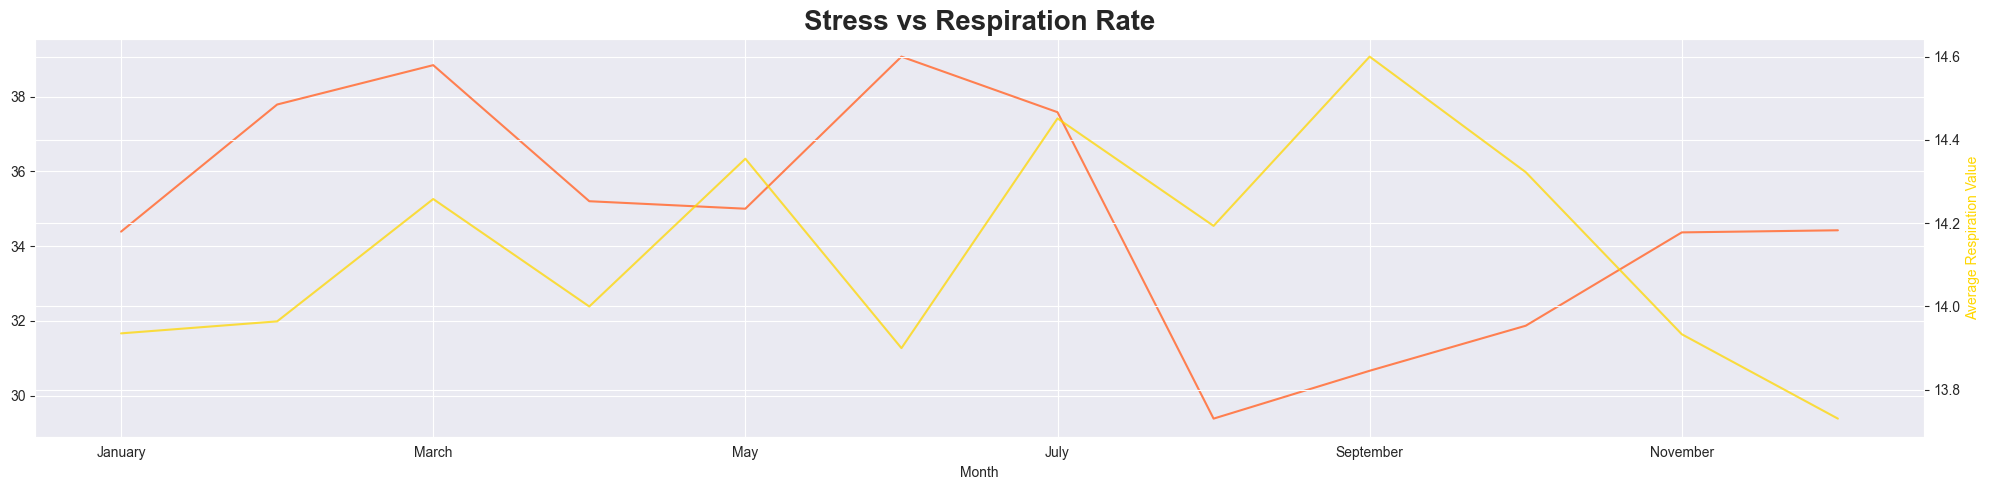

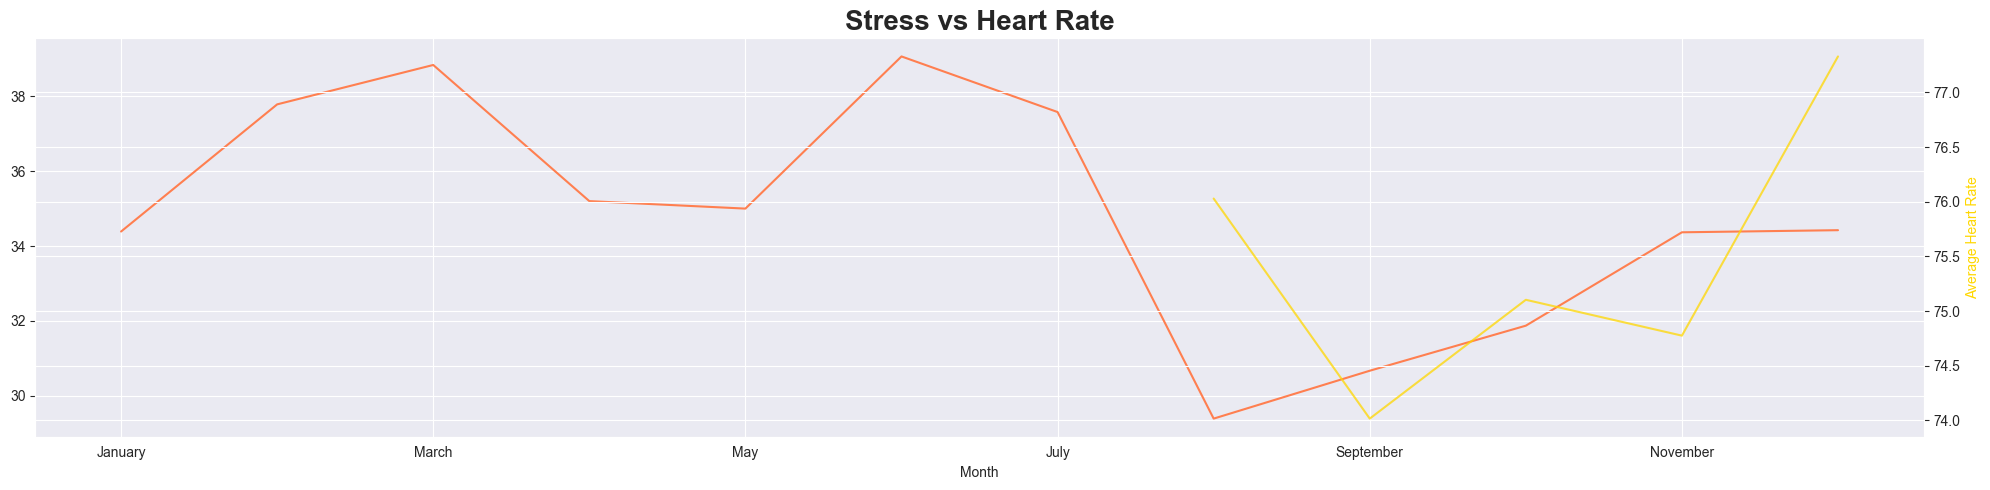

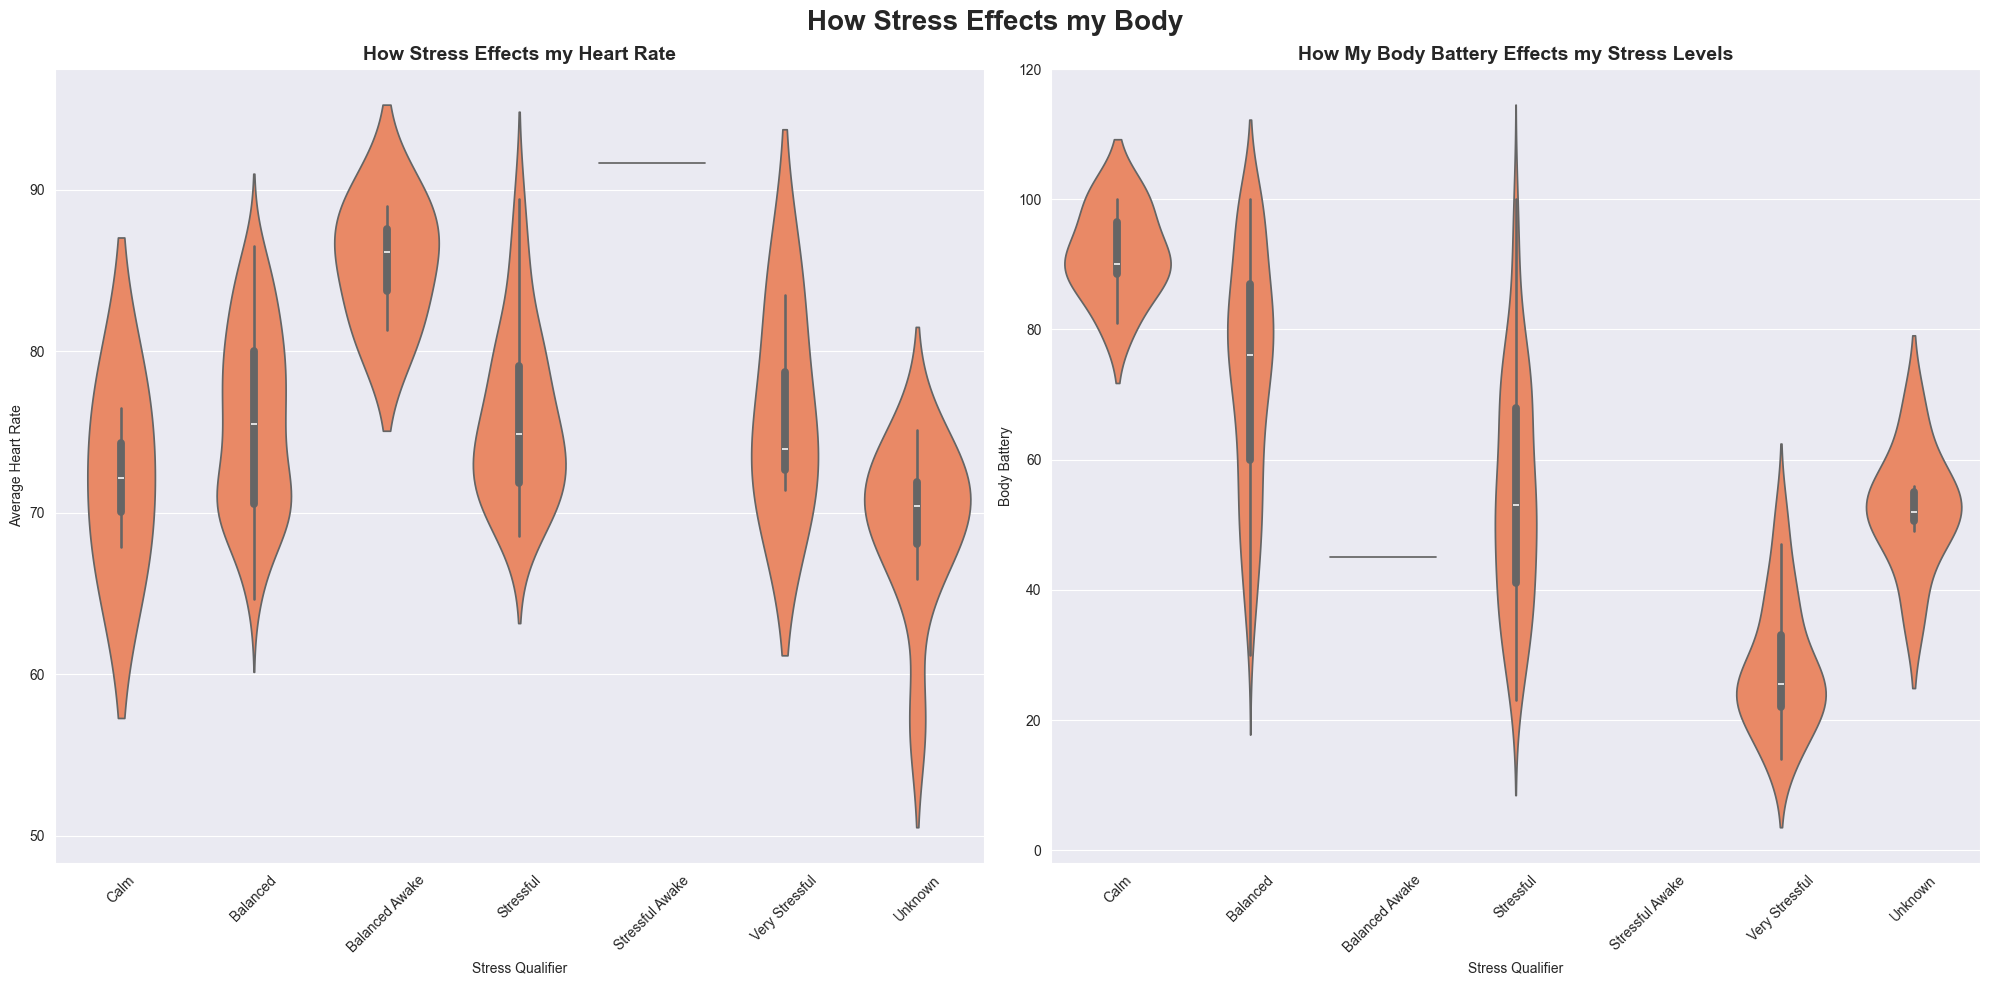

In [517]:
fix, ax1 = plt.subplots(figsize=[20,5])

grp_month['Average Stress Level'].mean().plot(color=MAIN_COLOR, ax=ax1)
ax2.set_ylabel('Average Stress Level', color=MAIN_COLOR)

ax2 = ax1.twinx()

grp_month['Avg Waking Respiration Value'].mean().plot(color=REF_COLOR, alpha=.75, ax=ax2)
ax2.set_ylabel('Average Respiration Value', color=REF_COLOR)

plt.title('Stress vs Respiration Rate', **TITLE_KKWARGS)

plt.tight_layout()
plt.show()

fix, ax1 = plt.subplots(figsize=[20,5])

grp_month['Average Stress Level'].mean().plot(color=MAIN_COLOR, ax=ax1)
ax2.set_ylabel('Average Stress Level', color=MAIN_COLOR)

ax2 = ax1.twinx()

grp_month['Average Heart Rate'].mean().plot(color=REF_COLOR, alpha=.75, ax=ax2)
ax2.set_ylabel('Average Heart Rate', color=REF_COLOR)

plt.title('Stress vs Heart Rate', **TITLE_KKWARGS)

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
fig.suptitle('How Stress Effects my Body', **TITLE_KKWARGS)

sns.violinplot(df_viz,
               x='Stress Qualifier',
               y='Average Heart Rate',
               color=MAIN_COLOR,
               order=['Calm', 'Balanced', 'Balanced Awake', 'Stressful', 'Stressful Awake', 'Very Stressful', 'Unknown'], ax=ax1)
ax1.set_title('How Stress Effects my Heart Rate', **SUB_TITLE_KKWARGS)
ax1.tick_params(axis='x', rotation=45)


sns.violinplot(df_viz,
               x='Stress Qualifier',
               y='Body Battery',
               color=MAIN_COLOR,
               order=['Calm', 'Balanced', 'Balanced Awake', 'Stressful', 'Stressful Awake', 'Very Stressful', 'Unknown'], ax=ax2)
ax2.set_title('How My Body Battery Effects my Stress Levels', **SUB_TITLE_KKWARGS)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Le